In [1]:
# %%
# ============================================================
# CELL 1: Imports and Configuration (HMI-ONLY)
# ============================================================
import os, warnings, numpy as np, pandas as pd
import torch, torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import models
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import sys
import time

print("Torch:", torch.__version__, " | Numpy:", np.__version__, " | Python:", sys.version)

warnings.filterwarnings("ignore")
torch.manual_seed(42)
np.random.seed(42)

device = "mps" if hasattr(torch.backends, "mps") and torch.backends.mps.is_available() else \
         ("cuda" if torch.cuda.is_available() else "cpu")
print("✅ Device:", device)

# ============================================================
# OPTIMIZED CONFIGURATION FOR 33 FLARES (HMI-ONLY: 5 CHANNELS)
# ============================================================
DATA_DIR = "preprocessed_data"
IMG_CHANNELS = 5   # ← CHANGED from 8 to 5 (HMI only)
IMG_SIZE = 256
EPOCHS = 100
BATCH_SIZE = 2
LR = 3e-4
WEIGHT_DECAY = 1e-4
SCHED_STEP, SCHED_GAMMA = 25, 0.5
TARGET_SCALE = 1e-4
LOSS_WEIGHTS = torch.tensor([0.5, 0.3, 0.2], dtype=torch.float32)

print(f"""
OPTIMIZED CONFIGURATION FOR 33 FLARES (HMI-ONLY):
- Channels: {IMG_CHANNELS} (HMI magnetic field only)
- Image Size: {IMG_SIZE}×{IMG_SIZE}
- Epochs: {EPOCHS}
- Batch Size: {BATCH_SIZE}
- Learning Rate: {LR}
- Scheduler: StepLR (step={SCHED_STEP}, gamma={SCHED_GAMMA})
""")

Torch: 2.8.0  | Numpy: 2.2.6  | Python: 3.11.13 (main, Jun  5 2025, 08:21:08) [Clang 14.0.6 ]
✅ Device: mps

OPTIMIZED CONFIGURATION FOR 33 FLARES (HMI-ONLY):
- Channels: 5 (HMI magnetic field only)
- Image Size: 256×256
- Epochs: 100
- Batch Size: 2
- Learning Rate: 0.0003
- Scheduler: StepLR (step=25, gamma=0.5)



In [2]:
# %%
# ============================================================
# CELL 2: Load Dataset (HMI-ONLY)
# ============================================================
# Extract only HMI channels (last 5) from the preprocessed data

try:
    X_full = np.load(os.path.join(DATA_DIR, "X_aiahmi_256.npy"))  # Load full 13-channel data
    Y = np.load(os.path.join(DATA_DIR, "Y_aiahmi_256.npy"))
    
    # ← CHANGED: Extract only HMI channels (last 5: indices 8-12)
    X = X_full[:, 8:, :, :]
    
    print(f"✅ Loaded 256×256 dataset (HMI-only)")
    print(f"   Full data: {X_full.shape}")
    print(f"   HMI-only: {X.shape} (extracted channels 8-12)")
    print(f"   Y: {Y.shape}")
    
except FileNotFoundError:
    print("⚠️  256×256 data not found, loading 128×128...")
    X_full = np.load(os.path.join(DATA_DIR, "X_aiahmi.npy"))
    Y = np.load(os.path.join(DATA_DIR, "Y_aiahmi.npy"))
    
    # ← CHANGED: Extract only HMI channels (last 5)
    X = X_full[:, 8:, :, :]
    
    print(f"⚠️  Using 128×128 dataset (HMI-only)")
    print(f"   Full data: {X_full.shape}")
    print(f"   HMI-only: {X.shape}")
    print(f"   Consider regenerating at 256×256 for better performance!")

# Verify channel count
assert X.shape[1] == 5, f"Expected 5 HMI channels, got {X.shape[1]}"

# Zero-mean target scaling
Y_scaled = (Y - Y.mean(axis=0)) / TARGET_SCALE
print(f"\nTarget scaling: Mean={Y.mean(axis=0)}, Scale={TARGET_SCALE}")

# Load flare IDs
flare_ids = pd.read_csv("flare_euv_targets_3day.csv")["flare_id"].tolist()
assert len(flare_ids) == len(X), f"Mismatch: {len(X)} samples vs {len(flare_ids)} flare IDs"
print(f"✅ Loaded {len(flare_ids)} flares")

# Print dataset statistics
print(f"\nDataset Statistics:")
print(f"  X shape: {X.shape} (N, 5_HMI_channels, 256, 256)")
print(f"  HMI channels: B_field, B_incl, B_azim, IC, M")
print(f"  Min/Max irradiance: {Y.min():.2e} / {Y.max():.2e}")
print(f"  Mean ± Std: {Y.mean():.2e} ± {Y.std():.2e}")

✅ Loaded 256×256 dataset (HMI-only)
   Full data: (33, 13, 256, 256)
   HMI-only: (33, 5, 256, 256) (extracted channels 8-12)
   Y: (33, 3)

Target scaling: Mean=[8.8646077e-05 8.8066365e-05 8.8103399e-05], Scale=0.0001
✅ Loaded 33 flares

Dataset Statistics:
  X shape: (33, 5, 256, 256) (N, 5_HMI_channels, 256, 256)
  HMI channels: B_field, B_incl, B_azim, IC, M
  Min/Max irradiance: 6.04e-05 / 1.21e-04
  Mean ± Std: 8.83e-05 ± 1.53e-05


In [3]:
# %%
# ============================================================
# CELL 3: Global Standardization + Dataset Class
# ============================================================
def compute_global_stats(X):
    """Compute per-channel mean and std across all samples"""
    C = X.shape[1]
    means = np.array([X[:, c].mean() for c in range(C)], dtype=np.float32)
    stds  = np.array([X[:, c].std() + 1e-6 for c in range(C)], dtype=np.float32)
    return means, stds

GLOBAL_MEAN, GLOBAL_STD = compute_global_stats(X)
print("✅ Global statistics computed")
print(f"   Channel means: {GLOBAL_MEAN[:3]}... (showing first 3)")
print(f"   Channel stds:  {GLOBAL_STD[:3]}... (showing first 3)")

class FlareDataset(Dataset):
    def __init__(self, X, Y, mean, std, augment=False):
        self.X = X.astype(np.float32)
        self.Y = Y.astype(np.float32)
        self.mean = mean.astype(np.float32)
        self.std = std.astype(np.float32)
        self.augment = augment
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        x = (self.X[idx] - self.mean[:, None, None]) / self.std[:, None, None]
        y = self.Y[idx]
        
        # Data augmentation for training (random flips)
        if self.augment and np.random.rand() > 0.5:
            x = np.flip(x, axis=1).copy()  # Horizontal flip
        if self.augment and np.random.rand() > 0.5:
            x = np.flip(x, axis=2).copy()  # Vertical flip
        
        return torch.tensor(x), torch.tensor(y)

print("✅ Dataset class ready (with augmentation support)")

✅ Global statistics computed
   Channel means: [0.617507  0.6338342 0.640915 ]... (showing first 3)
   Channel stds:  [0.42652717 0.43772355 0.44191468]... (showing first 3)
✅ Dataset class ready (with augmentation support)


In [4]:
# %%
# ============================================================
# CELL 4: IMPROVED MODEL - ResNet34 with Channel Attention (HMI-ONLY)
# ============================================================
class ChannelAttention(nn.Module):
    """Squeeze-and-Excitation block for channel attention"""
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        b, c, _, _ = x.size()
        # Global average pooling
        y = x.view(b, c, -1).mean(dim=2)
        # Channel attention
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)


class ImprovedEUVRegressor(nn.Module):
    """
    Enhanced ResNet34 with:
    - 5-channel input stem (HMI-only)
    - Channel attention
    - Dropout regularization
    - Optimized for 33-flare dataset
    """
    def __init__(self, in_channels=5, out_features=3, dropout=0.3):  # ← CHANGED default to 5
        super().__init__()
        
        # Load pretrained ResNet34 (more capacity than ResNet18)
        resnet = models.resnet34(weights=models.ResNet34_Weights.IMAGENET1K_V1)
        
        # Modify first conv for 5 channels (HMI-only)  # ← CHANGED comment
        first_conv = resnet.conv1
        resnet.conv1 = nn.Conv2d(
            in_channels, 
            first_conv.out_channels,
            kernel_size=first_conv.kernel_size,
            stride=first_conv.stride,
            padding=first_conv.padding,
            bias=False
        )
        
        # Initialize new channels intelligently
        with torch.no_grad():
            # Copy pretrained RGB weights to first 3 channels
            resnet.conv1.weight[:, :3] = first_conv.weight
            
            # Initialize remaining channels with mean of RGB
            mean_weights = first_conv.weight.mean(dim=1, keepdim=True)
            for i in range(3, in_channels):
                resnet.conv1.weight[:, i:i+1] = mean_weights
        
        # Add channel attention after each residual block
        self.attention1 = ChannelAttention(64)
        self.attention2 = ChannelAttention(128)
        self.attention3 = ChannelAttention(256)
        self.attention4 = ChannelAttention(512)
        
        # Store ResNet layers
        self.conv1 = resnet.conv1
        self.bn1 = resnet.bn1
        self.relu = resnet.relu
        self.maxpool = resnet.maxpool
        
        self.layer1 = resnet.layer1
        self.layer2 = resnet.layer2
        self.layer3 = resnet.layer3
        self.layer4 = resnet.layer4
        
        self.avgpool = resnet.avgpool
        
        # Enhanced regression head
        self.fc = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout / 2),
            nn.Linear(256, out_features)
        )
    
    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        
        x = self.layer1(x)
        x = self.attention1(x)
        
        x = self.layer2(x)
        x = self.attention2(x)
        
        x = self.layer3(x)
        x = self.attention3(x)
        
        x = self.layer4(x)
        x = self.attention4(x)
        
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        
        return x

# Test model (with 5 channels for HMI-only)  # ← CHANGED comment
test_model = ImprovedEUVRegressor(in_channels=5)  # ← CHANGED: explicit in_channels=5
total_params = sum(p.numel() for p in test_model.parameters())
trainable_params = sum(p.numel() for p in test_model.parameters() if p.requires_grad)

print("✅ ImprovedEUVRegressor (ResNet34 + Channel Attention) - HMI-ONLY")  # ← CHANGED
print(f"   Input channels: 5 (HMI magnetic field)")  # ← CHANGED
print(f"   Total parameters: {total_params:,}")
print(f"   Trainable parameters: {trainable_params:,}")
del test_model

✅ ImprovedEUVRegressor (ResNet34 + Channel Attention) - HMI-ONLY
   Input channels: 5 (HMI magnetic field)
   Total parameters: 21,466,563
   Trainable parameters: 21,466,563


In [5]:
# %%
# ============================================================
# CELL 5: Loss Function
# ============================================================
def loss_fn_weighted(pred, target, weights=LOSS_WEIGHTS):
    """Horizon-weighted MSE loss"""
    diff2 = (pred - target) ** 2
    weighted = diff2 * weights.to(pred.device)
    return weighted.mean()

print("✅ Weighted MSE loss function ready")
print(f"   Horizon weights: {LOSS_WEIGHTS.numpy()}")

✅ Weighted MSE loss function ready
   Horizon weights: [0.5 0.3 0.2]


In [6]:
# %%
# ============================================================
# CELL 6: Training Functions (OPTIMIZED)
# ============================================================
def train_one_epoch(model, loader, optimizer):
    """Train for one epoch with gradient clipping"""
    model.train()
    epoch_losses = []
    
    for xb, yb in loader:
        xb = xb.to(device, dtype=torch.float32)
        yb = yb.to(device, dtype=torch.float32)
        
        optimizer.zero_grad()
        pred = model(xb)
        loss = loss_fn_weighted(pred, yb)
        loss.backward()
        
        # Gradient clipping for stability
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        epoch_losses.append(loss.item())
    
    return np.mean(epoch_losses)


def validate_epoch(model, loader):
    """Validate without gradient computation"""
    model.eval()
    val_losses = []
    
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device, dtype=torch.float32)
            yb = yb.to(device, dtype=torch.float32)
            
            pred = model(xb)
            loss = loss_fn_weighted(pred, yb)
            val_losses.append(loss.item())
    
    return np.mean(val_losses)


def train_with_validation(model, train_loader, val_loader, epochs=EPOCHS, patience=50):
    """
    Train with validation-based early stopping
    OPTIMIZED FOR 33 FLARES
    """
    model = model.to(device, dtype=torch.float32)
    
    # Optimizer with weight decay
    optimizer = torch.optim.AdamW(
        model.parameters(), 
        lr=LR, 
        weight_decay=WEIGHT_DECAY,
        betas=(0.9, 0.999)
    )
    
    # Cosine annealing with warm restarts (better than StepLR)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, 
        T_0=20,  # Restart every 20 epochs
        T_mult=2  # Double restart interval each time
    )
    
    best_val_loss = float("inf")
    best_state = None
    patience_counter = 0
    
    print(f"   Training for up to {epochs} epochs (patience={patience})...")
    
    for ep in range(epochs):
        # Train
        train_loss = train_one_epoch(model, train_loader, optimizer)
        
        # Validate
        val_loss = validate_epoch(model, val_loader)
        
        # Step scheduler
        scheduler.step()
        
        # Get current learning rate
        current_lr = optimizer.param_groups[0]['lr']
        
        # Print progress
        if ep % 10 == 0 or ep == epochs - 1:
            print(f"   Epoch {ep:03d}/{epochs} | Train={train_loss:.6f} | Val={val_loss:.6f} | LR={current_lr:.2e}")
        
        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"   ⏹️  Early stopping at epoch {ep} (best val={best_val_loss:.6f})")
                break
    
    # Load best model
    if best_state is not None:
        model.load_state_dict(best_state)
        print(f"   ✅ Loaded best model (val loss: {best_val_loss:.6f})")
    
    return model

print("✅ Training functions ready")

✅ Training functions ready


In [8]:
# %%
# ============================================================
# CELL 7: Evaluation Function (FIXED)
# ============================================================
def evaluate(model, loader):
    """
    Comprehensive evaluation with multiple metrics
    FIXED: Handles single-sample test sets (LOFO)
    """
    model.eval()
    preds, trues = [], []
    
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device, dtype=torch.float32)
            yb = yb.to(device, dtype=torch.float32)
            p = model(xb)
            preds.extend(p.cpu().numpy())
            trues.extend(yb.cpu().numpy())
    
    # Denormalize
    preds = np.array(preds) * TARGET_SCALE + Y.mean(axis=0)
    trues = np.array(trues) * TARGET_SCALE + Y.mean(axis=0)
    
    # Flatten for global metrics
    preds_flat = preds.ravel()
    trues_flat = trues.ravel()
    
    # Global metrics (across all horizons)
    mae = mean_absolute_error(trues_flat, preds_flat)
    
    # Pearson correlation - handle single sample case
    if len(trues_flat) >= 2:
        r, p_value = pearsonr(trues_flat, preds_flat)
        r2 = r2_score(trues_flat, preds_flat)
    else:
        # For single sample, use absolute error as proxy
        r = np.nan
        p_value = np.nan
        r2 = np.nan
    
    # Per-horizon metrics
    mae_per_horizon = []
    r_per_horizon = []
    
    for i in range(3):
        # MAE per horizon (always computable)
        mae_h = mean_absolute_error(trues[:, i], preds[:, i])
        mae_per_horizon.append(mae_h)
        
        # Correlation per horizon (requires 2+ samples)
        if len(trues[:, i]) >= 2:
            r_h, _ = pearsonr(trues[:, i], preds[:, i])
            r_per_horizon.append(r_h)
        else:
            r_per_horizon.append(np.nan)
    
    return {
        'mae': mae,
        'r': r,
        'r2': r2,
        'p_value': p_value,
        'preds': preds,
        'trues': trues,
        'mae_per_horizon': mae_per_horizon,
        'r_per_horizon': r_per_horizon
    }

print("✅ Evaluation function ready (handles single-sample LOFO)")

✅ Evaluation function ready (handles single-sample LOFO)


In [9]:
# %%
# ============================================================
# CELL 8: CORRECTED LOFO CROSS-VALIDATION (HMI-ONLY, NO LEAKAGE)
# ============================================================
import csv

os.makedirs("results_hmi_only", exist_ok=True)  # ← CHANGED folder
results = []

print("\n" + "="*70)
print("LOFO CROSS-VALIDATION - HMI-ONLY BASELINE (NO LEAKAGE)")  # ← CHANGED
print("="*70)
print(f"Total flares: {len(flare_ids)}")
print(f"Channels: {IMG_CHANNELS} (HMI magnetic field only)")  # ← CHANGED
print(f"Train/Val/Test split: {len(flare_ids)-2} / 1 / 1 per fold")
print("="*70)

total_start_time = time.time()

for test_idx, test_flare in enumerate(flare_ids):
    fold_start_time = time.time()

    print(f"\n{'='*70}")
    print(f"FOLD {test_idx + 1}/{len(flare_ids)} | Test: {test_flare}")
    print(f"{'='*70}")

    # ---- 1) Create masks ----
    test_mask = np.zeros(len(X), dtype=bool)
    test_mask[test_idx] = True

    train_indices = np.where(~test_mask)[0]
    val_idx = train_indices[test_idx % len(train_indices)]  # rotate
    val_mask = np.zeros(len(X), dtype=bool)
    val_mask[val_idx] = True

    train_mask = ~test_mask & ~val_mask

    print(f"   Train: {np.sum(train_mask)} flares")
    print(f"   Val:   {flare_ids[val_idx]}")
    print(f"   Test:  {test_flare}")

    # ---- 2) TRAIN-ONLY NORMALIZATION  (NO LEAKAGE) ----
    X_train = X[train_mask]  # (Ntrain, C, H, W)
    train_mean = X_train.mean(axis=(0, 2, 3))
    train_std  = X_train.std(axis=(0, 2, 3)) + 1e-6

    print(f"   🔍 Train-only normalization applied")
    print(f"      Mean: {train_mean[:3]}..., Std: {train_std[:3]}...")

    # ---- 3) CREATE DATASETS (using ONLY train stats) ----
    ds_train = FlareDataset(X[train_mask], Y_scaled[train_mask],
                            train_mean, train_std, augment=True)
    ds_val   = FlareDataset(X[val_mask],   Y_scaled[val_mask],
                            train_mean, train_std, augment=False)
    ds_test  = FlareDataset(X[test_mask],  Y_scaled[test_mask],
                            train_mean, train_std, augment=False)

    train_loader = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True)
    val_loader   = DataLoader(ds_val,   batch_size=1, shuffle=False)
    test_loader  = DataLoader(ds_test,  batch_size=1, shuffle=False)

    # ---- 4) Initialize model (HMI-only: 5 channels) ----
    model = ImprovedEUVRegressor(in_channels=5, out_features=3, dropout=0.3)  # ← CHANGED to 5
    model = train_with_validation(model, train_loader, val_loader,
                                  epochs=EPOCHS, patience=50)

    # ---- 5) Save & Evaluate ----
    model_path = f"results_hmi_only/{test_flare}_model.pth"  # ← CHANGED folder
    torch.save(model.state_dict(), model_path)

    metrics = evaluate(model, test_loader)
    results.append((test_flare, metrics))

    np.savez(f"results_hmi_only/{test_flare}_preds.npz",  # ← CHANGED folder
             flare=test_flare, preds=metrics['preds'], trues=metrics['trues'])

    fold_time = time.time() - fold_start_time

    print(f"\n   📊 Test Metrics:")
    print(f"      MAE:       {metrics['mae']:.6e}")
    print(f"      Pearson r: {metrics['r']:.3f} (p={metrics['p_value']:.3e})")
    print(f"      R²:        {metrics['r2']:.3f}")
    print(f"      Horizon MAE: T0={metrics['mae_per_horizon'][0]:.2e}, "
          f"T1={metrics['mae_per_horizon'][1]:.2e}, T2={metrics['mae_per_horizon'][2]:.2e}")
    print(f"   ⏱️  Fold time: {fold_time/60:.1f} minutes")

# ---- 6) Summary ----
total_time = time.time() - total_start_time

print("\n" + "="*70)
print("LOFO COMPLETE - HMI-ONLY BASELINE (SAFELY NORMALIZED)")  # ← CHANGED
print("="*70)
print(f"Total time: {total_time/60:.1f} minutes ({total_time/3600:.1f} hours)")
print(f"Avg per fold: {total_time/len(flare_ids)/60:.1f} minutes\n")

all_maes = [m['mae'] for _, m in results]
all_r2s  = [m['r2'] for _, m in results if not np.isnan(m['r2'])]

print("SUMMARY STATISTICS:")
print(f"  MAE: {np.mean(all_maes):.6e} ± {np.std(all_maes):.6e}")
if len(all_r2s):
    print(f"  R² : {np.mean(all_r2s):.3f} ± {np.std(all_r2s):.3f}")
else:
    print(f"  R² : Not computable (single sample per test)")

# ---- 7) Export Summary ----
with open("results_hmi_only/summary.csv", "w", newline="") as f:  # ← CHANGED folder
    w = csv.writer(f)
    w.writerow(["flare_id", "MAE", "MAE_T0", "MAE_T1", "MAE_T2"])
    for fid, m in results:
        w.writerow([
            fid,
            f"{m['mae']:.6e}",
            f"{m['mae_per_horizon'][0]:.6e}",
            f"{m['mae_per_horizon'][1]:.6e}",
            f"{m['mae_per_horizon'][2]:.6e}"
        ])

print("✅ SAFE RESULTS SAVED to results_hmi_only/")  # ← CHANGED folder


LOFO CROSS-VALIDATION - HMI-ONLY BASELINE (NO LEAKAGE)
Total flares: 33
Channels: 5 (HMI magnetic field only)
Train/Val/Test split: 31 / 1 / 1 per fold

FOLD 1/33 | Test: AR11158_M6.6
   Train: 31 flares
   Val:   AR11158_X2.2
   Test:  AR11158_M6.6
   🔍 Train-only normalization applied
      Mean: [0.615924  0.632793  0.6398436]..., Std: [0.426506  0.4381281 0.4422981]...
   Training for up to 100 epochs (patience=50)...
   Epoch 000/100 | Train=0.015564 | Val=0.009029 | LR=2.98e-04
   Epoch 010/100 | Train=0.005602 | Val=0.020444 | LR=1.27e-04
   Epoch 020/100 | Train=0.004512 | Val=0.011340 | LR=3.00e-04
   Epoch 030/100 | Train=0.003301 | Val=0.024177 | LR=2.47e-04
   Epoch 040/100 | Train=0.001840 | Val=0.020124 | LR=1.38e-04
   Epoch 050/100 | Train=0.001113 | Val=0.015877 | LR=3.59e-05
   Epoch 060/100 | Train=0.001266 | Val=0.023986 | LR=3.00e-04
   Epoch 070/100 | Train=0.001506 | Val=0.008360 | LR=2.86e-04
   ⏹️  Early stopping at epoch 78 (best val=0.000080)
   ✅ Loaded bes


GENERATING GLOBAL SCATTER PLOT (HMI-ONLY BASELINE)
Plotting 99 total predictions...

✅ Saved:
   - figures/global_scatter_hmi_only.pdf
   - figures/global_scatter_hmi_only.png


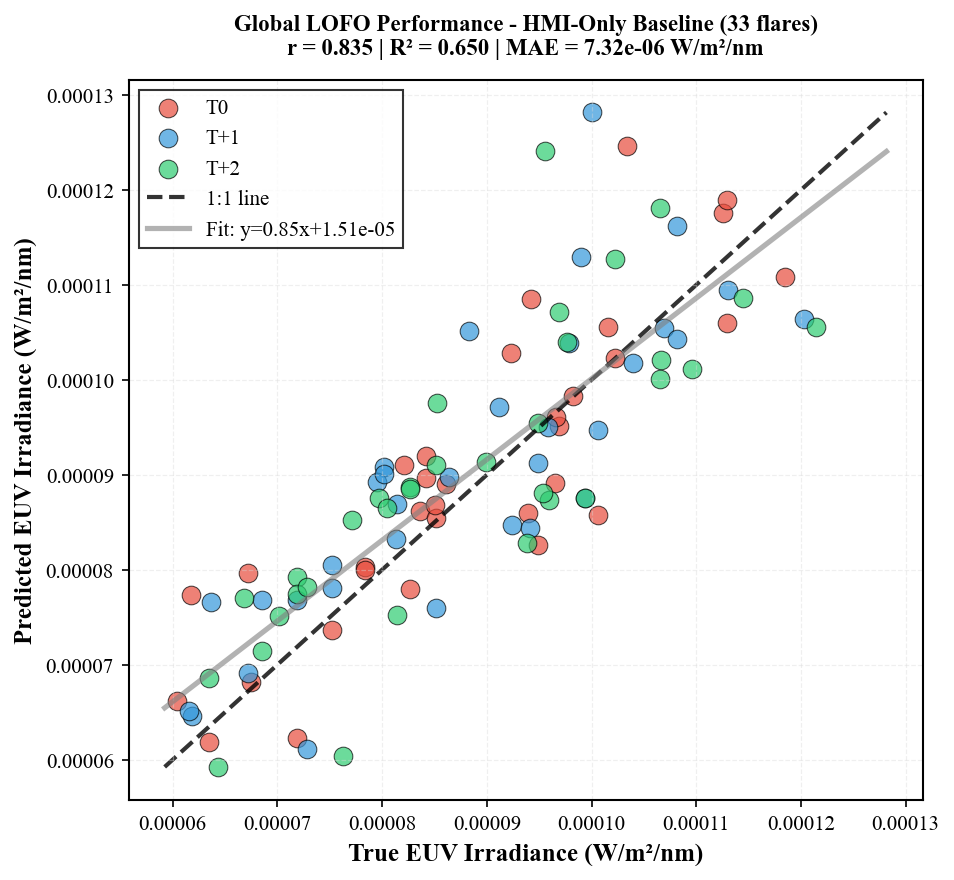


GENERATING PER-HORIZON SCATTER PLOTS (HMI-ONLY)

✅ Saved:
   - figures/per_horizon_scatter_hmi_only.pdf
   - figures/per_horizon_scatter_hmi_only.png


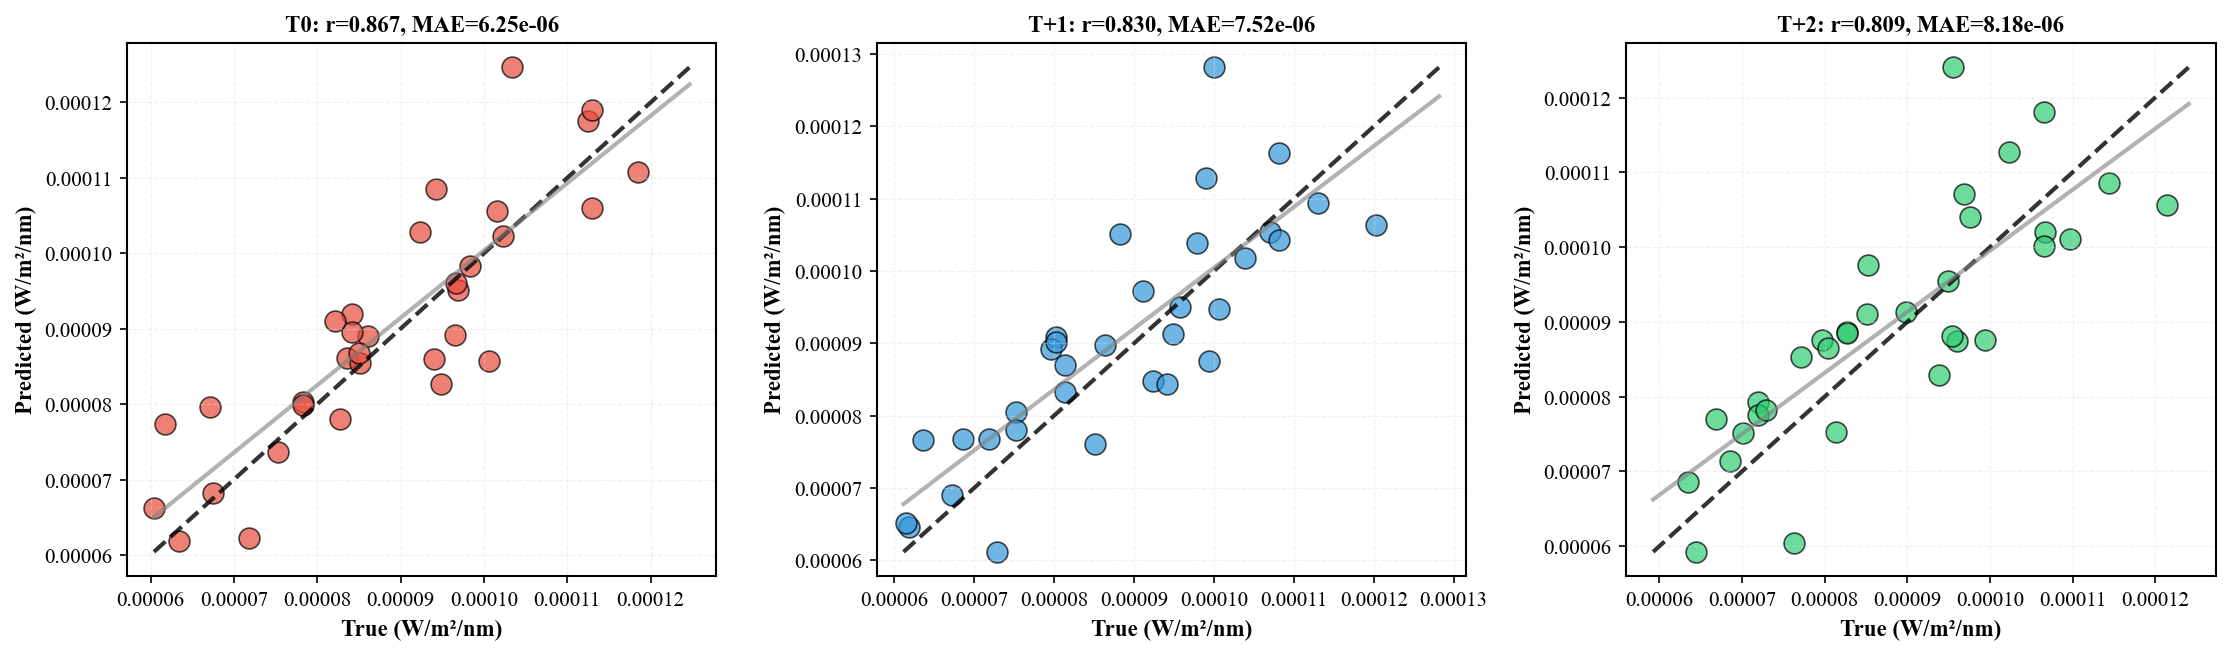


RESIDUAL ANALYSIS (HMI-ONLY)

✅ Saved:
   - figures/residual_analysis_hmi_only.pdf
   - figures/residual_analysis_hmi_only.png


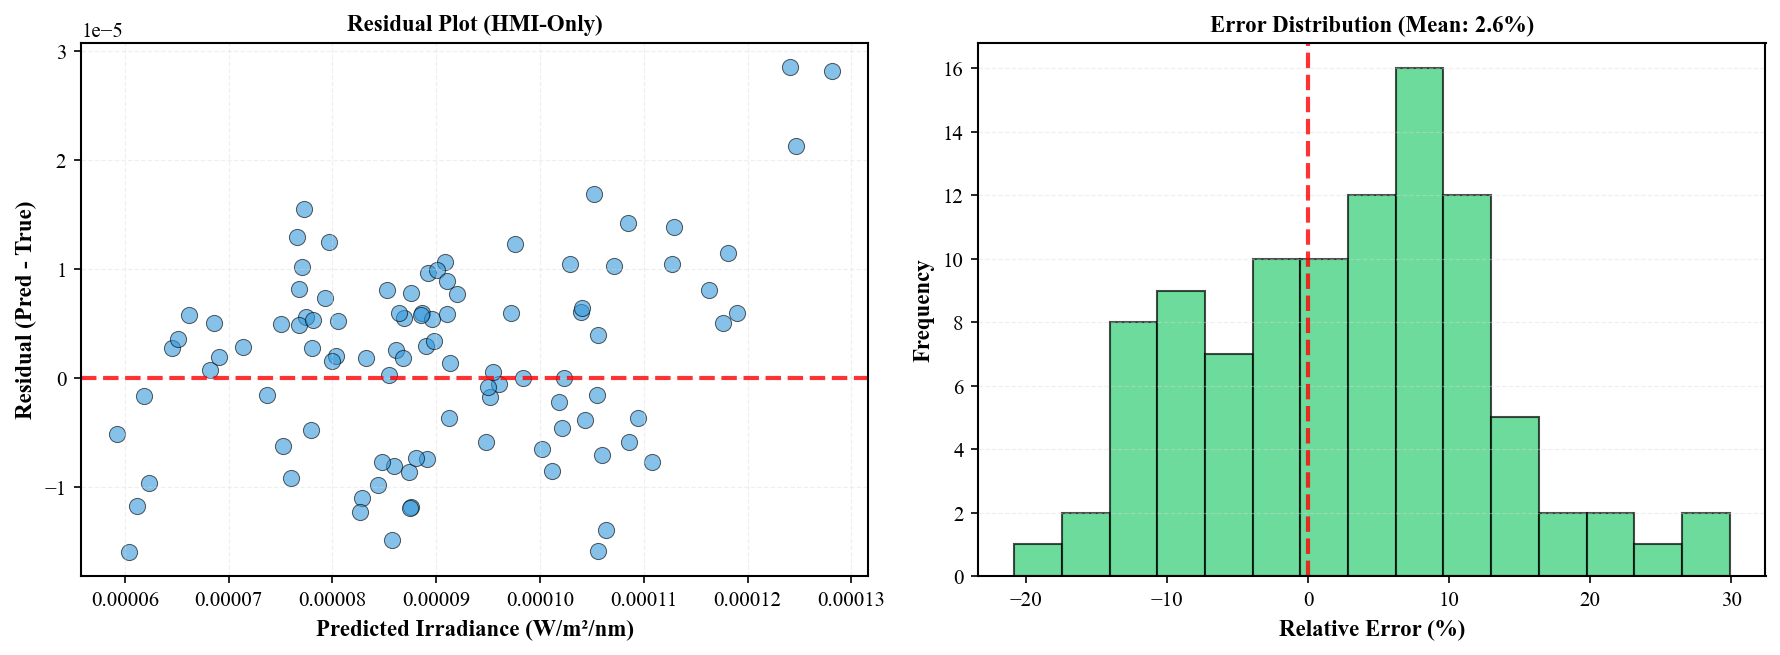


PER-FLARE PERFORMANCE SUMMARY (HMI-ONLY)

✅ Saved:
   - figures/per_flare_performance_hmi_only.pdf
   - figures/per_flare_performance_hmi_only.png


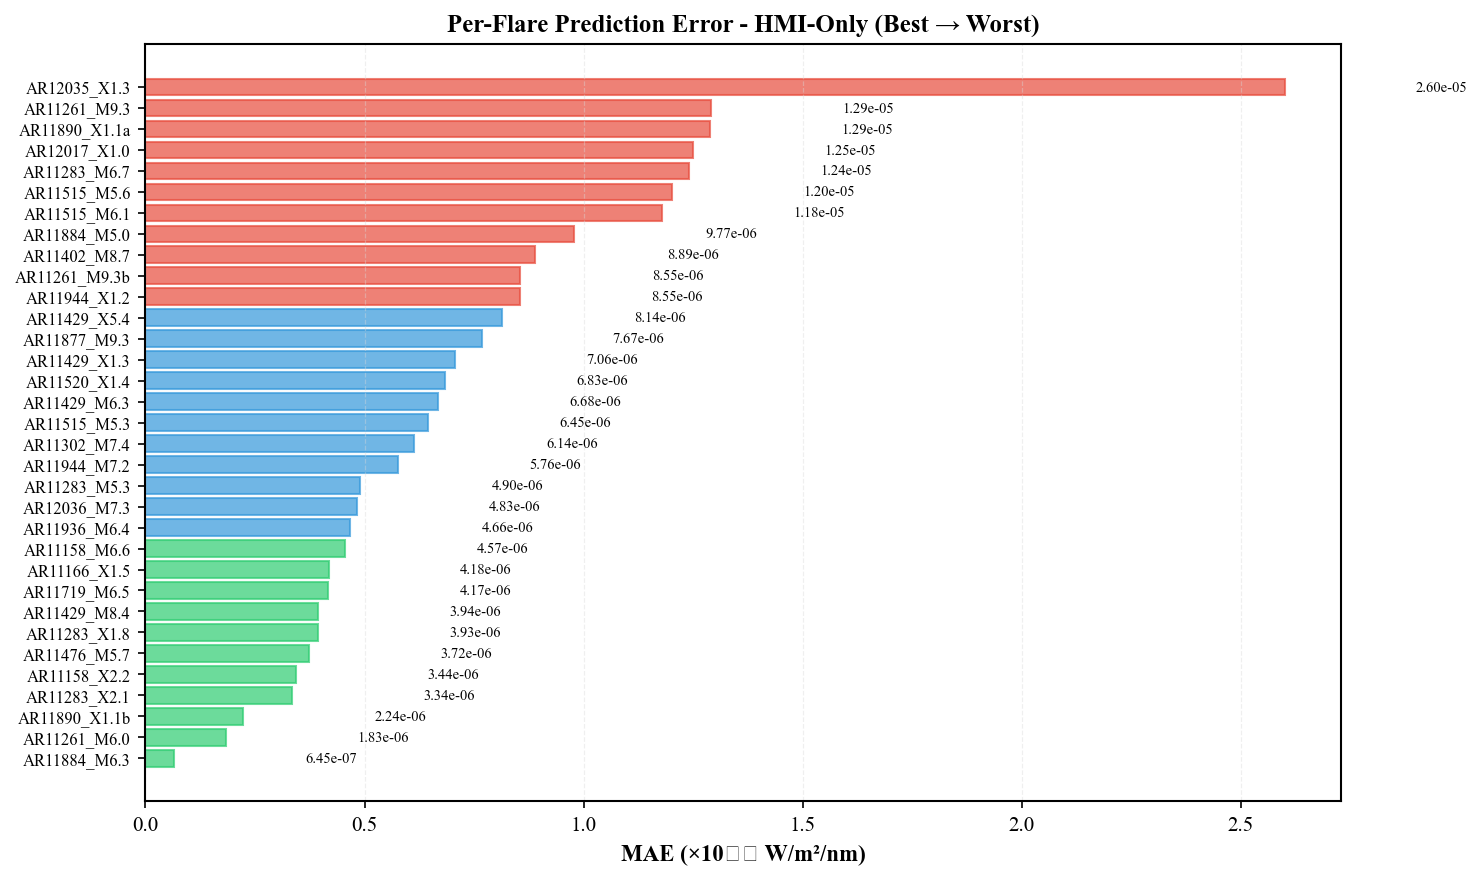


FLARE PERFORMANCE TABLE (HMI-ONLY, Sorted by MAE)
Rank  Flare ID             MAE (W/m²/nm)      Quality
----------------------------------------------------------------------
1     AR11884_M6.3         6.451883e-07       ✅ Excellent
2     AR11261_M6.0         1.834885e-06       ✅ Excellent
3     AR11890_X1.1b        2.236278e-06       ✅ Excellent
4     AR11283_X2.1         3.344830e-06       ✅ Excellent
5     AR11158_X2.2         3.440152e-06       ✅ Excellent
6     AR11476_M5.7         3.722397e-06       ✅ Excellent
7     AR11283_X1.8         3.928246e-06       ✅ Excellent
8     AR11429_M8.4         3.941949e-06       ✅ Excellent
9     AR11719_M6.5         4.172808e-06       ✅ Excellent
10    AR11166_X1.5         4.180479e-06       ✅ Excellent
11    AR11158_M6.6         4.565152e-06       ✅ Excellent
12    AR11936_M6.4         4.664299e-06       ✅ Excellent
13    AR12036_M7.3         4.832109e-06       ✅ Excellent
14    AR11283_M5.3         4.895849e-06       ✅ Excellent
15    AR1194

In [11]:
# %%
# ============================================================
# CELL 10: GLOBAL SCATTER PLOT + DETAILED ANALYSIS (HMI-ONLY)
# ============================================================
from matplotlib import rcParams
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt
import os

# IEEE-style formatting
rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 11,
    "axes.labelweight": "bold",
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.linewidth": 1.0,
    "legend.fontsize": 9,
    "legend.frameon": True,
    "grid.color": "0.85",
    "grid.linestyle": "--",
    "grid.linewidth": 0.6
})

print("\n" + "="*70)
print("GENERATING GLOBAL SCATTER PLOT (HMI-ONLY BASELINE)")  # ← CHANGED
print("="*70)

# Get flattened predictions
preds_flat = all_preds.ravel()
trues_flat = all_trues.ravel()

print(f"Plotting {len(preds_flat)} total predictions...")

# Create figure
fig, ax = plt.subplots(figsize=(6.5, 6), dpi=150)

# Scatter plot with different colors for each horizon
colors = ['#E74C3C', '#3498DB', '#2ECC71']  # Red, Blue, Green
labels = ['T0', 'T+1', 'T+2']

for i, (color, label) in enumerate(zip(colors, labels)):
    horizon_preds = all_preds[:, i]
    horizon_trues = all_trues[:, i]
    ax.scatter(horizon_trues, horizon_preds, 
              s=80, alpha=0.7, c=color, 
              edgecolors='black', linewidth=0.5,
              label=label, marker='o')

# 1:1 reference line
min_val = min(trues_flat.min(), preds_flat.min())
max_val = max(trues_flat.max(), preds_flat.max())
ax.plot([min_val, max_val], [min_val, max_val], 
        'k--', lw=2, alpha=0.8, label='1:1 line', zorder=1)

# Linear regression fit
lr = LinearRegression()
lr.fit(trues_flat.reshape(-1, 1), preds_flat)
pred_line = lr.predict(np.array([min_val, max_val]).reshape(-1, 1))
ax.plot([min_val, max_val], pred_line, 
        'gray', lw=2.5, alpha=0.6, linestyle='-',
        label=f'Fit: y={lr.coef_[0]:.2f}x{lr.intercept_:+.2e}')

# Labels and formatting
ax.set_xlabel('True EUV Irradiance (W/m²/nm)', fontweight='bold', fontsize=12)
ax.set_ylabel('Predicted EUV Irradiance (W/m²/nm)', fontweight='bold', fontsize=12)

# Title with metrics (mention HMI-only)  # ← CHANGED
title_text = (f'Global LOFO Performance - HMI-Only Baseline ({len(all_preds)} flares)\n'
             f'r = {global_r:.3f} | R² = {global_r2:.3f} | '
             f'MAE = {global_mae:.2e} W/m²/nm')
ax.set_title(title_text, fontweight='bold', fontsize=11, pad=12)

# Legend
ax.legend(loc='upper left', frameon=True, edgecolor='black', 
         fancybox=False, shadow=False, fontsize=10)

# Grid
ax.grid(True, alpha=0.4, linestyle='--', linewidth=0.6)

# Tight layout
plt.tight_layout()

# Save (with hmi_only in filename)  # ← CHANGED
os.makedirs("figures", exist_ok=True)
plt.savefig("figures/global_scatter_hmi_only.pdf", dpi=300, bbox_inches='tight')
plt.savefig("figures/global_scatter_hmi_only.png", dpi=300, bbox_inches='tight')

print("\n✅ Saved:")
print("   - figures/global_scatter_hmi_only.pdf")  # ← CHANGED
print("   - figures/global_scatter_hmi_only.png")  # ← CHANGED

plt.show()

# ============================================================
# Per-Horizon Scatter Plots (Separate)
# ============================================================
print("\n" + "="*70)
print("GENERATING PER-HORIZON SCATTER PLOTS (HMI-ONLY)")  # ← CHANGED
print("="*70)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), dpi=150)

for i, (ax, color, label) in enumerate(zip(axes, colors, labels)):
    horizon_preds = all_preds[:, i]
    horizon_trues = all_trues[:, i]
    
    # Scatter
    ax.scatter(horizon_trues, horizon_preds,
              s=100, alpha=0.7, c=color,
              edgecolors='black', linewidth=0.8)
    
    # 1:1 line
    h_min = min(horizon_trues.min(), horizon_preds.min())
    h_max = max(horizon_trues.max(), horizon_preds.max())
    ax.plot([h_min, h_max], [h_min, h_max],
           'k--', lw=2, alpha=0.8)
    
    # Linear fit
    lr_h = LinearRegression()
    lr_h.fit(horizon_trues.reshape(-1, 1), horizon_preds)
    pred_line_h = lr_h.predict(np.array([h_min, h_max]).reshape(-1, 1))
    ax.plot([h_min, h_max], pred_line_h,
           'gray', lw=2, alpha=0.6)
    
    # Metrics
    mae_h = mean_absolute_error(horizon_trues, horizon_preds)
    r_h, p_h = pearsonr(horizon_trues, horizon_preds)
    
    # Labels
    ax.set_xlabel('True (W/m²/nm)', fontweight='bold')
    ax.set_ylabel('Predicted (W/m²/nm)', fontweight='bold')
    ax.set_title(f'{label}: r={r_h:.3f}, MAE={mae_h:.2e}',
                fontweight='bold', fontsize=11)
    ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig("figures/per_horizon_scatter_hmi_only.pdf", dpi=300, bbox_inches='tight')  # ← CHANGED
plt.savefig("figures/per_horizon_scatter_hmi_only.png", dpi=300, bbox_inches='tight')  # ← CHANGED

print("\n✅ Saved:")
print("   - figures/per_horizon_scatter_hmi_only.pdf")  # ← CHANGED
print("   - figures/per_horizon_scatter_hmi_only.png")  # ← CHANGED

plt.show()

# ============================================================
# Residual Analysis
# ============================================================
print("\n" + "="*70)
print("RESIDUAL ANALYSIS (HMI-ONLY)")  # ← CHANGED
print("="*70)

residuals = preds_flat - trues_flat
relative_residuals = residuals / (trues_flat + 1e-8) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), dpi=150)

# Residuals vs Predicted
axes[0].scatter(preds_flat, residuals, 
               s=60, alpha=0.6, c='#3498DB',
               edgecolors='black', linewidth=0.5)
axes[0].axhline(y=0, color='red', linestyle='--', lw=2, alpha=0.8)
axes[0].set_xlabel('Predicted Irradiance (W/m²/nm)', fontweight='bold')
axes[0].set_ylabel('Residual (Pred - True)', fontweight='bold')
axes[0].set_title('Residual Plot (HMI-Only)', fontweight='bold')  # ← CHANGED
axes[0].grid(True, alpha=0.4)

# Residual histogram
axes[1].hist(relative_residuals, bins=15, 
            color='#2ECC71', alpha=0.7, 
            edgecolor='black', linewidth=1)
axes[1].axvline(x=0, color='red', linestyle='--', lw=2, alpha=0.8)
axes[1].set_xlabel('Relative Error (%)', fontweight='bold')
axes[1].set_ylabel('Frequency', fontweight='bold')
axes[1].set_title(f'Error Distribution (Mean: {relative_residuals.mean():.1f}%)',
                 fontweight='bold')
axes[1].grid(True, alpha=0.4, axis='y')

plt.tight_layout()
plt.savefig("figures/residual_analysis_hmi_only.pdf", dpi=300, bbox_inches='tight')  # ← CHANGED
plt.savefig("figures/residual_analysis_hmi_only.png", dpi=300, bbox_inches='tight')  # ← CHANGED

print("\n✅ Saved:")
print("   - figures/residual_analysis_hmi_only.pdf")  # ← CHANGED
print("   - figures/residual_analysis_hmi_only.png")  # ← CHANGED

plt.show()

# ============================================================
# Per-Flare Performance Summary
# ============================================================
print("\n" + "="*70)
print("PER-FLARE PERFORMANCE SUMMARY (HMI-ONLY)")  # ← CHANGED
print("="*70)

flare_names = [fid for fid, _ in results]
flare_maes = [m['mae'] for _, m in results]

# Sort by MAE
sorted_indices = np.argsort(flare_maes)
sorted_names = [flare_names[i] for i in sorted_indices]
sorted_maes = [flare_maes[i] for i in sorted_indices]

fig, ax = plt.subplots(figsize=(10, 6), dpi=150)

bars = ax.barh(range(len(sorted_names)), 
              np.array(sorted_maes) * 1e5,  # Scale to ×10⁻⁵
              color='#3498DB', alpha=0.7,
              edgecolor='black', linewidth=1)

# Color gradient (best to worst)
for i, bar in enumerate(bars):
    if i < len(bars) // 3:
        bar.set_color('#2ECC71')  # Green for best
    elif i < 2 * len(bars) // 3:
        bar.set_color('#3498DB')  # Blue for medium
    else:
        bar.set_color('#E74C3C')  # Red for worst

ax.set_yticks(range(len(sorted_names)))
ax.set_yticklabels(sorted_names, fontsize=8)
ax.set_xlabel('MAE (×10⁻⁵ W/m²/nm)', fontweight='bold', fontsize=11)
ax.set_title('Per-Flare Prediction Error - HMI-Only (Best → Worst)',  # ← CHANGED
            fontweight='bold', fontsize=12)
ax.grid(True, alpha=0.4, axis='x')

# Add value labels
for i, (name, mae) in enumerate(zip(sorted_names, sorted_maes)):
    ax.text(mae * 1e5 + 0.3, i, f'{mae:.2e}',
           va='center', fontsize=7)

plt.tight_layout()
plt.savefig("figures/per_flare_performance_hmi_only.pdf", dpi=300, bbox_inches='tight')  # ← CHANGED
plt.savefig("figures/per_flare_performance_hmi_only.png", dpi=300, bbox_inches='tight')  # ← CHANGED

print("\n✅ Saved:")
print("   - figures/per_flare_performance_hmi_only.pdf")  # ← CHANGED
print("   - figures/per_flare_performance_hmi_only.png")  # ← CHANGED

plt.show()

# Print summary table
print("\n" + "="*70)
print("FLARE PERFORMANCE TABLE (HMI-ONLY, Sorted by MAE)")  # ← CHANGED
print("="*70)
print(f"{'Rank':<5} {'Flare ID':<20} {'MAE (W/m²/nm)':<18} {'Quality'}")
print("-"*70)

for rank, (name, mae) in enumerate(zip(sorted_names, sorted_maes), 1):
    if mae < 5e-6:
        quality = "✅ Excellent"
    elif mae < 1e-5:
        quality = "✅ Good"
    elif mae < 1.5e-5:
        quality = "⚠️  Fair"
    else:
        quality = "❌ Challenging"
    
    print(f"{rank:<5} {name:<20} {mae:<18.6e} {quality}")

print("\n" + "="*70)
print("✅ CELL 10 COMPLETE - ALL HMI-ONLY VISUALIZATIONS GENERATED")  # ← CHANGED
print("="*70)


GLOBAL SCATTER PLOT - HMI-ONLY BASELINE

Data loaded: 33 flares × 3 horizons = 99 predictions

--- Global Metrics (HMI-Only) ---
Linear correction: y_true ≈ 0.821 * pred + 1.425e-05
Raw correlation (r)       = 0.835 (p=5.75e-27)
Corrected correlation (r) = 0.835
Global R²                 = 0.650
Global MAE                = 7.32e-06 W/m²/nm
Global Relative Error     = 8.4%

✅ Saved:
   - figures/HMI_only_raw_corrected.pdf
   - figures/HMI_only_raw_corrected.png


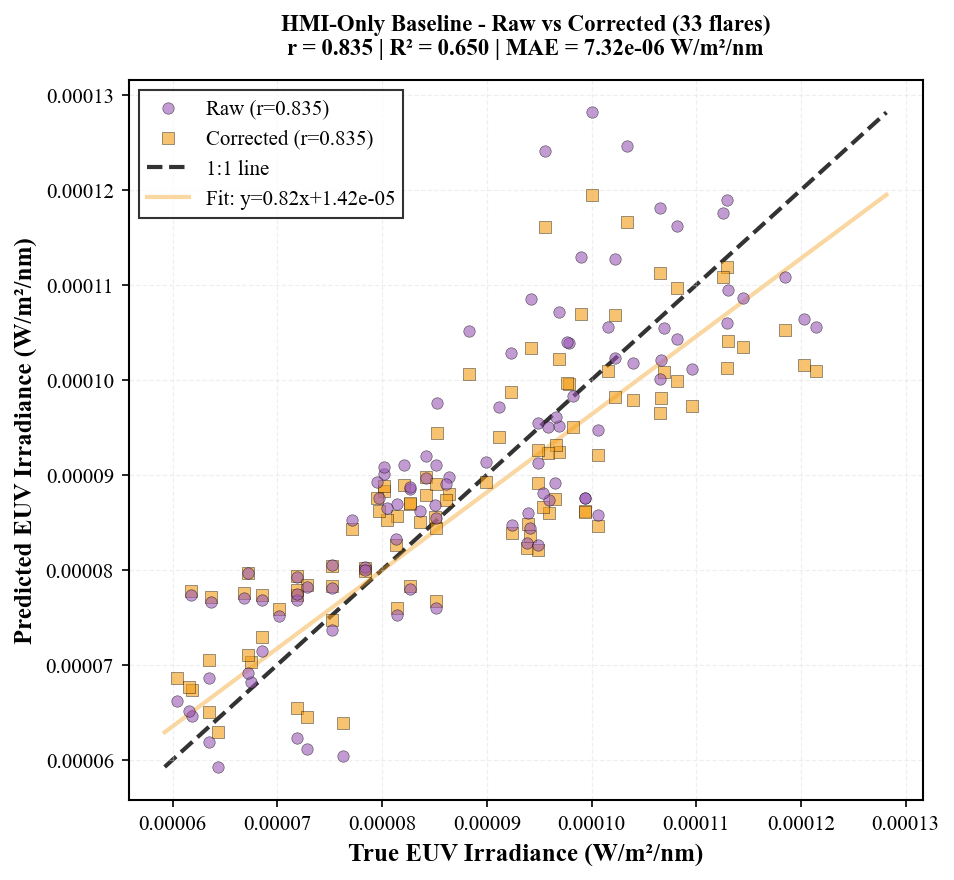

   - figures/HMI_only_scatter_metrics.json



In [13]:
# %%
# ============================================================
# 📊 Global Metrics & Scatter Plot - HMI-Only (Current Results)
# ============================================================

import matplotlib.pyplot as plt
from matplotlib import rcParams
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from scipy.stats import pearsonr
import numpy as np
import json
import os

# --- Load results from HMI-only LOFO ---
results_folder = "results_hmi_only"

# Load predictions from all folds
all_preds = []
all_trues = []

for npz_file in sorted(os.listdir(results_folder)):
    if npz_file.endswith("_preds.npz"):
        data = np.load(os.path.join(results_folder, npz_file))
        all_preds.append(data['preds'])
        all_trues.append(data['trues'])

# Concatenate all predictions
pred_all = np.concatenate(all_preds, axis=0)  # Shape: (33, 3)
true_all = np.concatenate(all_trues, axis=0)  # Shape: (33, 3)

# Flatten for global correlation
pred_flat = pred_all.ravel()
true_flat = true_all.ravel()

print("\n" + "="*70)
print("GLOBAL SCATTER PLOT - HMI-ONLY BASELINE")
print("="*70)
print(f"\nData loaded: {len(pred_all)} flares × 3 horizons = {len(pred_flat)} predictions")

# --- IEEE-style formatting ---
rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 11,
    "axes.labelweight": "bold",
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.linewidth": 1.0,
    "legend.fontsize": 9,
    "legend.frameon": True,
    "grid.color": "0.85",
    "grid.linestyle": "--",
    "grid.linewidth": 0.6
})

# --- Compute metrics ---
corr_raw, p_value = pearsonr(true_flat, pred_flat)
r2 = r2_score(true_flat, pred_flat)
mae = mean_absolute_error(true_flat, pred_flat)
rel_err = np.mean(np.abs((pred_flat - true_flat) / (true_flat + 1e-8)))

# --- Linear correction fit ---
lr = LinearRegression().fit(pred_flat.reshape(-1, 1), true_flat)
pred_corrected = lr.predict(pred_flat.reshape(-1, 1))
corr_corr, _ = pearsonr(true_flat, pred_corrected)

print("\n--- Global Metrics (HMI-Only) ---")
print(f"Linear correction: y_true ≈ {lr.coef_[0]:.3f} * pred + {lr.intercept_:.3e}")
print(f"Raw correlation (r)       = {corr_raw:.3f} (p={p_value:.2e})")
print(f"Corrected correlation (r) = {corr_corr:.3f}")
print(f"Global R²                 = {r2:.3f}")
print(f"Global MAE                = {mae:.2e} W/m²/nm")
print(f"Global Relative Error     = {rel_err*100:.1f}%")

# --- Create scatter plot ---
fig, ax = plt.subplots(figsize=(6.5, 6), dpi=150)

# Plot raw and corrected predictions
ax.scatter(true_flat, pred_flat, 
          s=30, c="#9B59B6", alpha=0.6,  # ← Purple for HMI
          edgecolors='black', linewidth=0.3,
          label=f"Raw (r={corr_raw:.3f})", 
          marker='o', zorder=3)

ax.scatter(true_flat, pred_corrected, 
          s=30, c="#F39C12", alpha=0.6,  # ← Orange for corrected
          edgecolors='black', linewidth=0.3,
          label=f"Corrected (r={corr_corr:.3f})", 
          marker='s', zorder=2)

# 1:1 reference line
min_val = min(true_flat.min(), pred_flat.min())
max_val = max(true_flat.max(), pred_flat.max())
ax.plot([min_val, max_val], [min_val, max_val], 
        'k--', lw=2, alpha=0.8, label='1:1 line', zorder=1)

# Correction line
ax.plot([min_val, max_val], 
        lr.predict(np.array([min_val, max_val]).reshape(-1, 1)),
        color='#F39C12', lw=2, alpha=0.4, linestyle='-',
        label=f'Fit: y={lr.coef_[0]:.2f}x{lr.intercept_:+.2e}',
        zorder=1)

# Labels and formatting
ax.set_xlabel('True EUV Irradiance (W/m²/nm)', fontweight='bold', fontsize=12)
ax.set_ylabel('Predicted EUV Irradiance (W/m²/nm)', fontweight='bold', fontsize=12)

# Title with metrics
title_text = (f'HMI-Only Baseline - Raw vs Corrected ({len(pred_all)} flares)\n'
             f'r = {corr_raw:.3f} | R² = {r2:.3f} | '
             f'MAE = {mae:.2e} W/m²/nm')
ax.set_title(title_text, fontweight='bold', fontsize=11, pad=12)

# Legend
ax.legend(loc='upper left', frameon=True, edgecolor='black', 
         fancybox=False, shadow=False, fontsize=10)

# Grid
ax.grid(True, alpha=0.4, linestyle='--', linewidth=0.6)

# Tight layout
plt.tight_layout()

# Save
os.makedirs("figures", exist_ok=True)
plt.savefig("figures/HMI_only_raw_corrected.pdf", dpi=600, bbox_inches='tight')
plt.savefig("figures/HMI_only_raw_corrected.png", dpi=600, bbox_inches='tight')

print("\n✅ Saved:")
print("   - figures/HMI_only_raw_corrected.pdf")
print("   - figures/HMI_only_raw_corrected.png")

plt.show()

# --- Save metrics to JSON ---
scatter_metrics = {
    'model': 'HMI-Only Baseline',
    'n_flares': int(len(pred_all)),
    'n_predictions': int(len(pred_flat)),
    'raw_correlation': float(corr_raw),
    'corrected_correlation': float(corr_corr),
    'r2': float(r2),
    'mae': float(mae),
    'relative_error_pct': float(rel_err * 100),
    'linear_fit': {
        'slope': float(lr.coef_[0]),
        'intercept': float(lr.intercept_)
    }
}

with open("figures/HMI_only_scatter_metrics.json", "w") as f:
    json.dump(scatter_metrics, f, indent=2)

print("   - figures/HMI_only_scatter_metrics.json")
print("\n" + "="*70)


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


✅ Saved: figures/flare_euv_architecture_ieee.pdf
✅ Saved: figures/flare_euv_architecture_ieee.png
✅ Saved: figures/flare_euv_architecture_ieee.eps


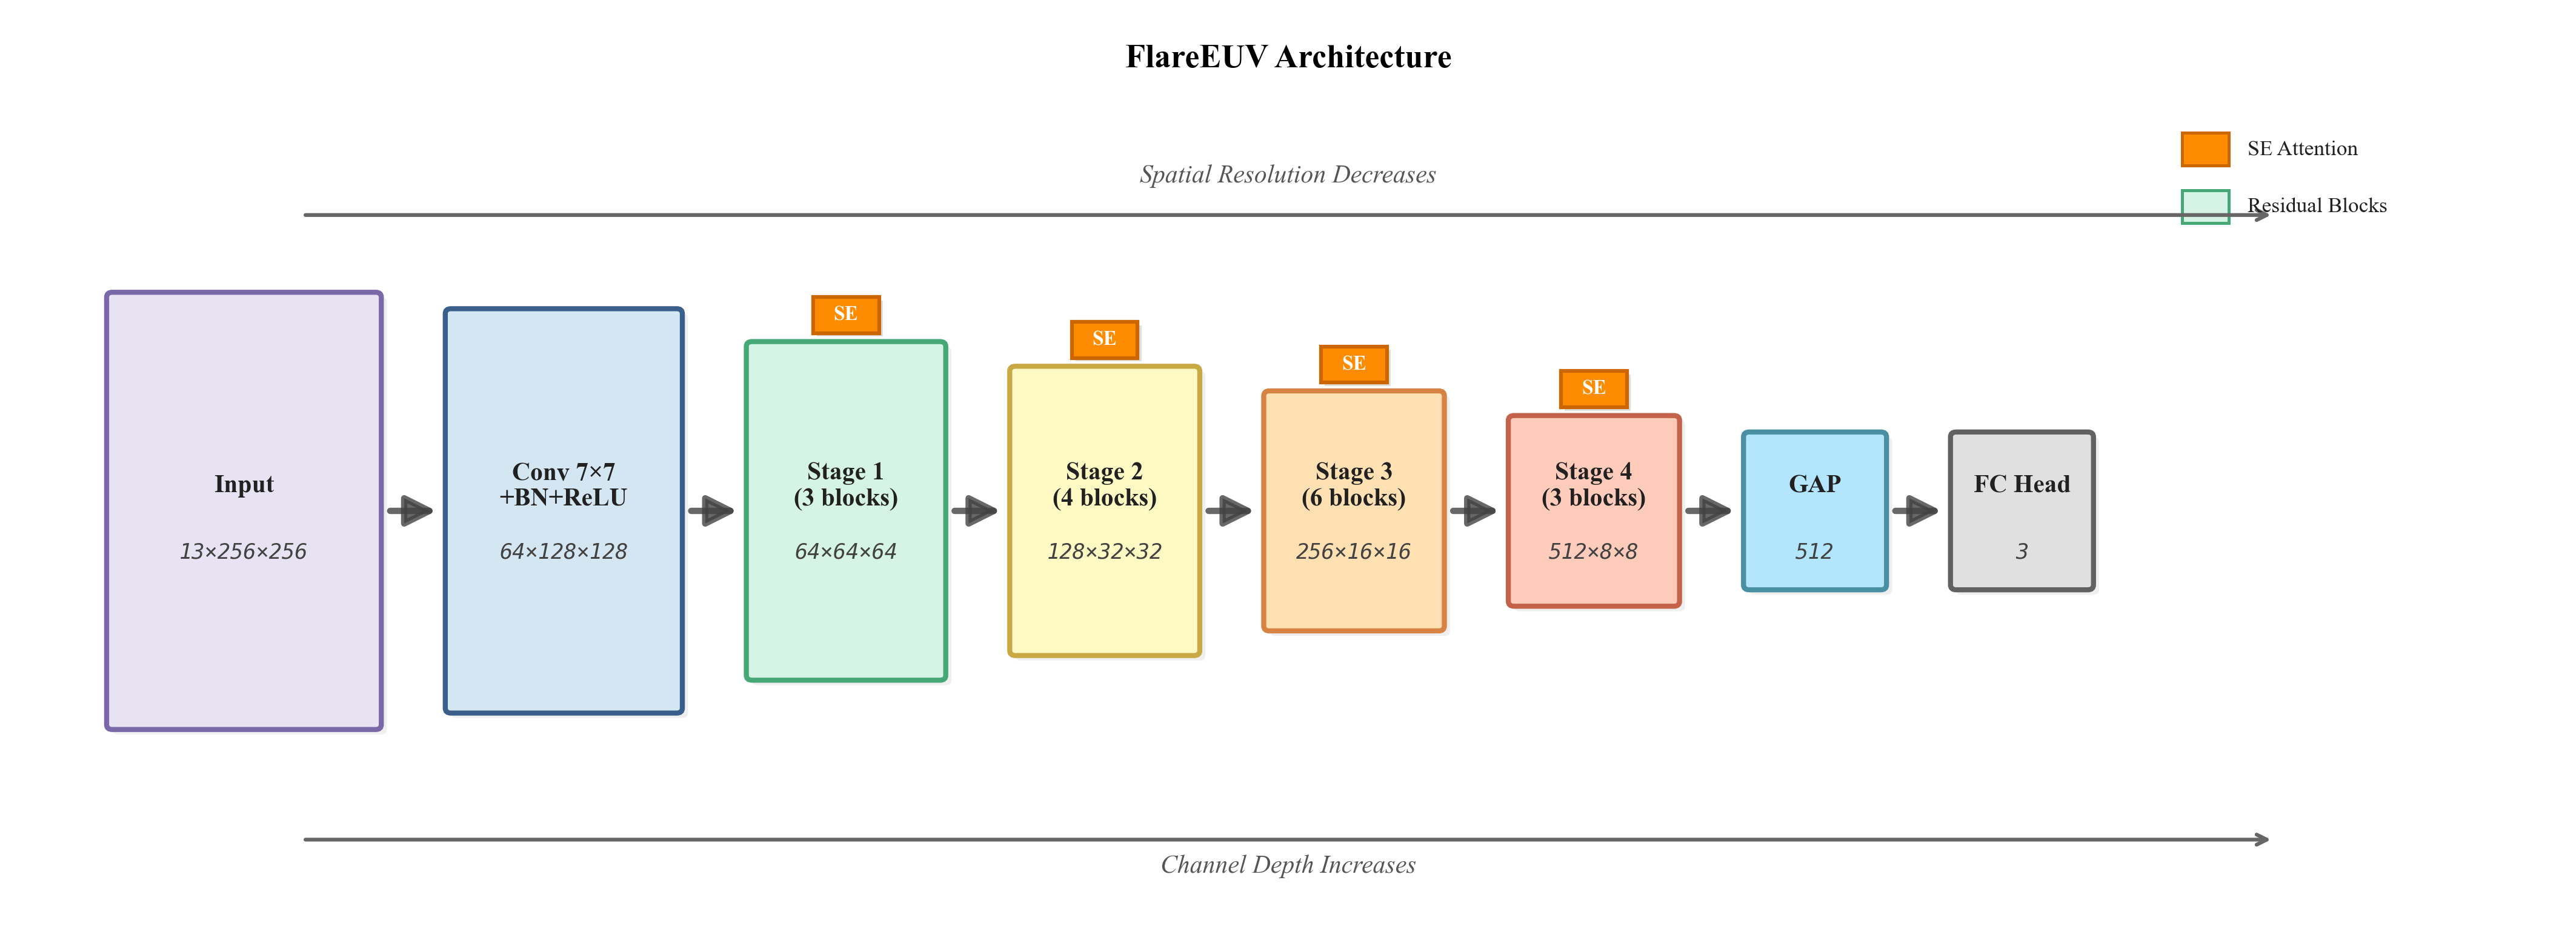

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Rectangle
import numpy as np

def create_ieee_architecture():
    """Create IEEE-style professional architecture diagram"""
    
    # IEEE style parameters
    plt.rcParams.update({
        'font.family': 'serif',
        'font.serif': ['Times New Roman'],
        'font.size': 10,
        'axes.labelweight': 'bold',
        'axes.linewidth': 1.0,
        'figure.dpi': 300
    })
    
    fig, ax = plt.subplots(figsize=(14, 5), dpi=300)
    
    # Define stages with IEEE color scheme (more professional, less saturated)
    stages = [
        # (name, width, height, dims_text, color, outline_color)
        ("Input", 1.4, 2.6, "13×256×256", '#E8E3F3', '#7B68A8'),
        ("Conv 7×7\n+BN+ReLU", 1.2, 2.4, "64×128×128", '#D4E6F1', '#3A5F8A'),
        ("Stage 1\n(3 blocks)", 1.0, 2.0, "64×64×64", '#D5F4E6', '#45A876'),
        ("Stage 2\n(4 blocks)", 0.95, 1.7, "128×32×32", '#FFF9C4', '#C9A944'),
        ("Stage 3\n(6 blocks)", 0.9, 1.4, "256×16×16", '#FFE0B2', '#D68344'),
        ("Stage 4\n(3 blocks)", 0.85, 1.1, "512×8×8", '#FFCCBC', '#C5634A'),
        ("GAP", 0.7, 0.9, "512", '#B3E5FC', '#4A90A4'),
        ("FC Head", 0.7, 0.9, "3", '#E0E0E0', '#616161')
    ]
    
    x_pos = 0.5
    spacing = 0.4
    y_center = 2.5
    
    # Store positions for arrows
    box_positions = []
    
    for i, (name, width, height, dims, fill_color, edge_color) in enumerate(stages):
        y = y_center - height/2
        
        # Draw main box with shadow effect
        shadow = FancyBboxPatch(
            (x_pos + 0.03, y - 0.03), width, height,
            boxstyle="round,pad=0.03",
            facecolor='#CCCCCC', edgecolor='none',
            alpha=0.3, zorder=1
        )
        ax.add_patch(shadow)
        
        # Main box
        box = FancyBboxPatch(
            (x_pos, y), width, height,
            boxstyle="round,pad=0.03",
            facecolor=fill_color, 
            edgecolor=edge_color,
            linewidth=2.0, 
            alpha=1.0,
            zorder=2
        )
        ax.add_patch(box)
        
        # Stage name (bold)
        ax.text(x_pos + width/2, y + height/2 + 0.15, name,
               ha='center', va='center', 
               fontsize=10, weight='bold',
               color='#212121', zorder=3)
        
        # Dimensions (italic, smaller)
        ax.text(x_pos + width/2, y + height/2 - 0.25, dims,
               ha='center', va='center', 
               fontsize=8.5, style='italic',
               color='#424242', family='monospace',
               zorder=3)
        
        # SE Attention blocks (for stages 1-4)
        if 2 <= i <= 5:
            se_width = 0.35
            se_height = 0.22
            se_x = x_pos + width/2 - se_width/2
            se_y = y + height + 0.08
            
            # SE box shadow
            se_shadow = Rectangle(
                (se_x + 0.02, se_y - 0.02), se_width, se_height,
                facecolor='#999999', edgecolor='none',
                alpha=0.3, zorder=1
            )
            ax.add_patch(se_shadow)
            
            # SE box
            se_box = Rectangle(
                (se_x, se_y), se_width, se_height,
                facecolor='#FF8C00', edgecolor='#CC6600',
                linewidth=1.5, zorder=2
            )
            ax.add_patch(se_box)
            
            ax.text(se_x + se_width/2, se_y + se_height/2, 'SE',
                   ha='center', va='center', 
                   fontsize=8, weight='bold',
                   color='white', zorder=3)
        
        box_positions.append((x_pos, width, y, height))
        x_pos += width + spacing
    
    # Draw arrows between stages
    for i in range(len(box_positions) - 1):
        x1, w1, y1, h1 = box_positions[i]
        x2, w2, y2, h2 = box_positions[i + 1]
        
        arrow_y = y_center
        arrow = FancyArrowPatch(
            (x1 + w1 + 0.05, arrow_y),
            (x2 - 0.05, arrow_y),
            arrowstyle='-|>',
            mutation_scale=25,
            linewidth=2.5,
            color='#424242',
            alpha=0.8,
            zorder=1
        )
        ax.add_patch(arrow)
    
    # Add directional annotations (IEEE style - clean and minimal)
    ax.annotate('', xy=(12, 4.3), xytext=(1.5, 4.3),
               arrowprops=dict(arrowstyle='->', lw=1.5, color='#666666'))
    ax.text(6.75, 4.5, 'Spatial Resolution Decreases', 
           fontsize=10, ha='center', style='italic', color='#555555')
    
    ax.annotate('', xy=(12, 0.5), xytext=(1.5, 0.5),
               arrowprops=dict(arrowstyle='->', lw=1.5, color='#666666'))
    ax.text(6.75, 0.3, 'Channel Depth Increases', 
           fontsize=10, ha='center', style='italic', color='#555555')
    
    # Title (IEEE style - centered, bold)
    ax.text(6.75, 5.2, 'FlareEUV Architecture', 
           fontsize=13, ha='center', weight='bold', family='serif')
    
    # Legend (IEEE style - clean boxes)
    legend_x = 11.5
    legend_y = 4.6
    legend_width = 0.25
    legend_height = 0.2
    legend_spacing = 0.35
    
    # SE Attention
    leg_se = Rectangle((legend_x, legend_y), legend_width, legend_height,
                       facecolor='#FF8C00', edgecolor='#CC6600', linewidth=1.2)
    ax.add_patch(leg_se)
    ax.text(legend_x + legend_width + 0.1, legend_y + legend_height/2, 
           'SE Attention',
           va='center', fontsize=8.5, color='#212121')
    
    # Residual Blocks
    leg_res = Rectangle((legend_x, legend_y - legend_spacing), 
                        legend_width, legend_height,
                        facecolor='#D5F4E6', edgecolor='#45A876', linewidth=1.2)
    ax.add_patch(leg_res)
    ax.text(legend_x + legend_width + 0.1, 
           legend_y - legend_spacing + legend_height/2,
           'Residual Blocks',
           va='center', fontsize=8.5, color='#212121')
    
    # Set limits and clean up
    ax.set_xlim(0, 13.5)
    ax.set_ylim(0, 5.5)
    ax.axis('off')
    
    # Tight layout for IEEE paper
    plt.tight_layout(pad=0.1)
    
    # Save in multiple formats
    plt.savefig('figures/flare_euv_architecture_ieee.pdf', 
               dpi=300, bbox_inches='tight', pad_inches=0.05)
    plt.savefig('figures/flare_euv_architecture_ieee.png', 
               dpi=300, bbox_inches='tight', pad_inches=0.05)
    plt.savefig('figures/flare_euv_architecture_ieee.eps', 
               format='eps', bbox_inches='tight', pad_inches=0.05)
    
    print("✅ Saved: figures/flare_euv_architecture_ieee.pdf")
    print("✅ Saved: figures/flare_euv_architecture_ieee.png")
    print("✅ Saved: figures/flare_euv_architecture_ieee.eps")
    
    plt.show()


if __name__ == "__main__":
    create_ieee_architecture()

✅ Saved: figures/flare_euv_architecture_final.pdf


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


✅ Saved: figures/flare_euv_architecture_final.png
✅ Saved: figures/flare_euv_architecture_final.eps
✅ Saved: figures/flare_euv_architecture_final.svg


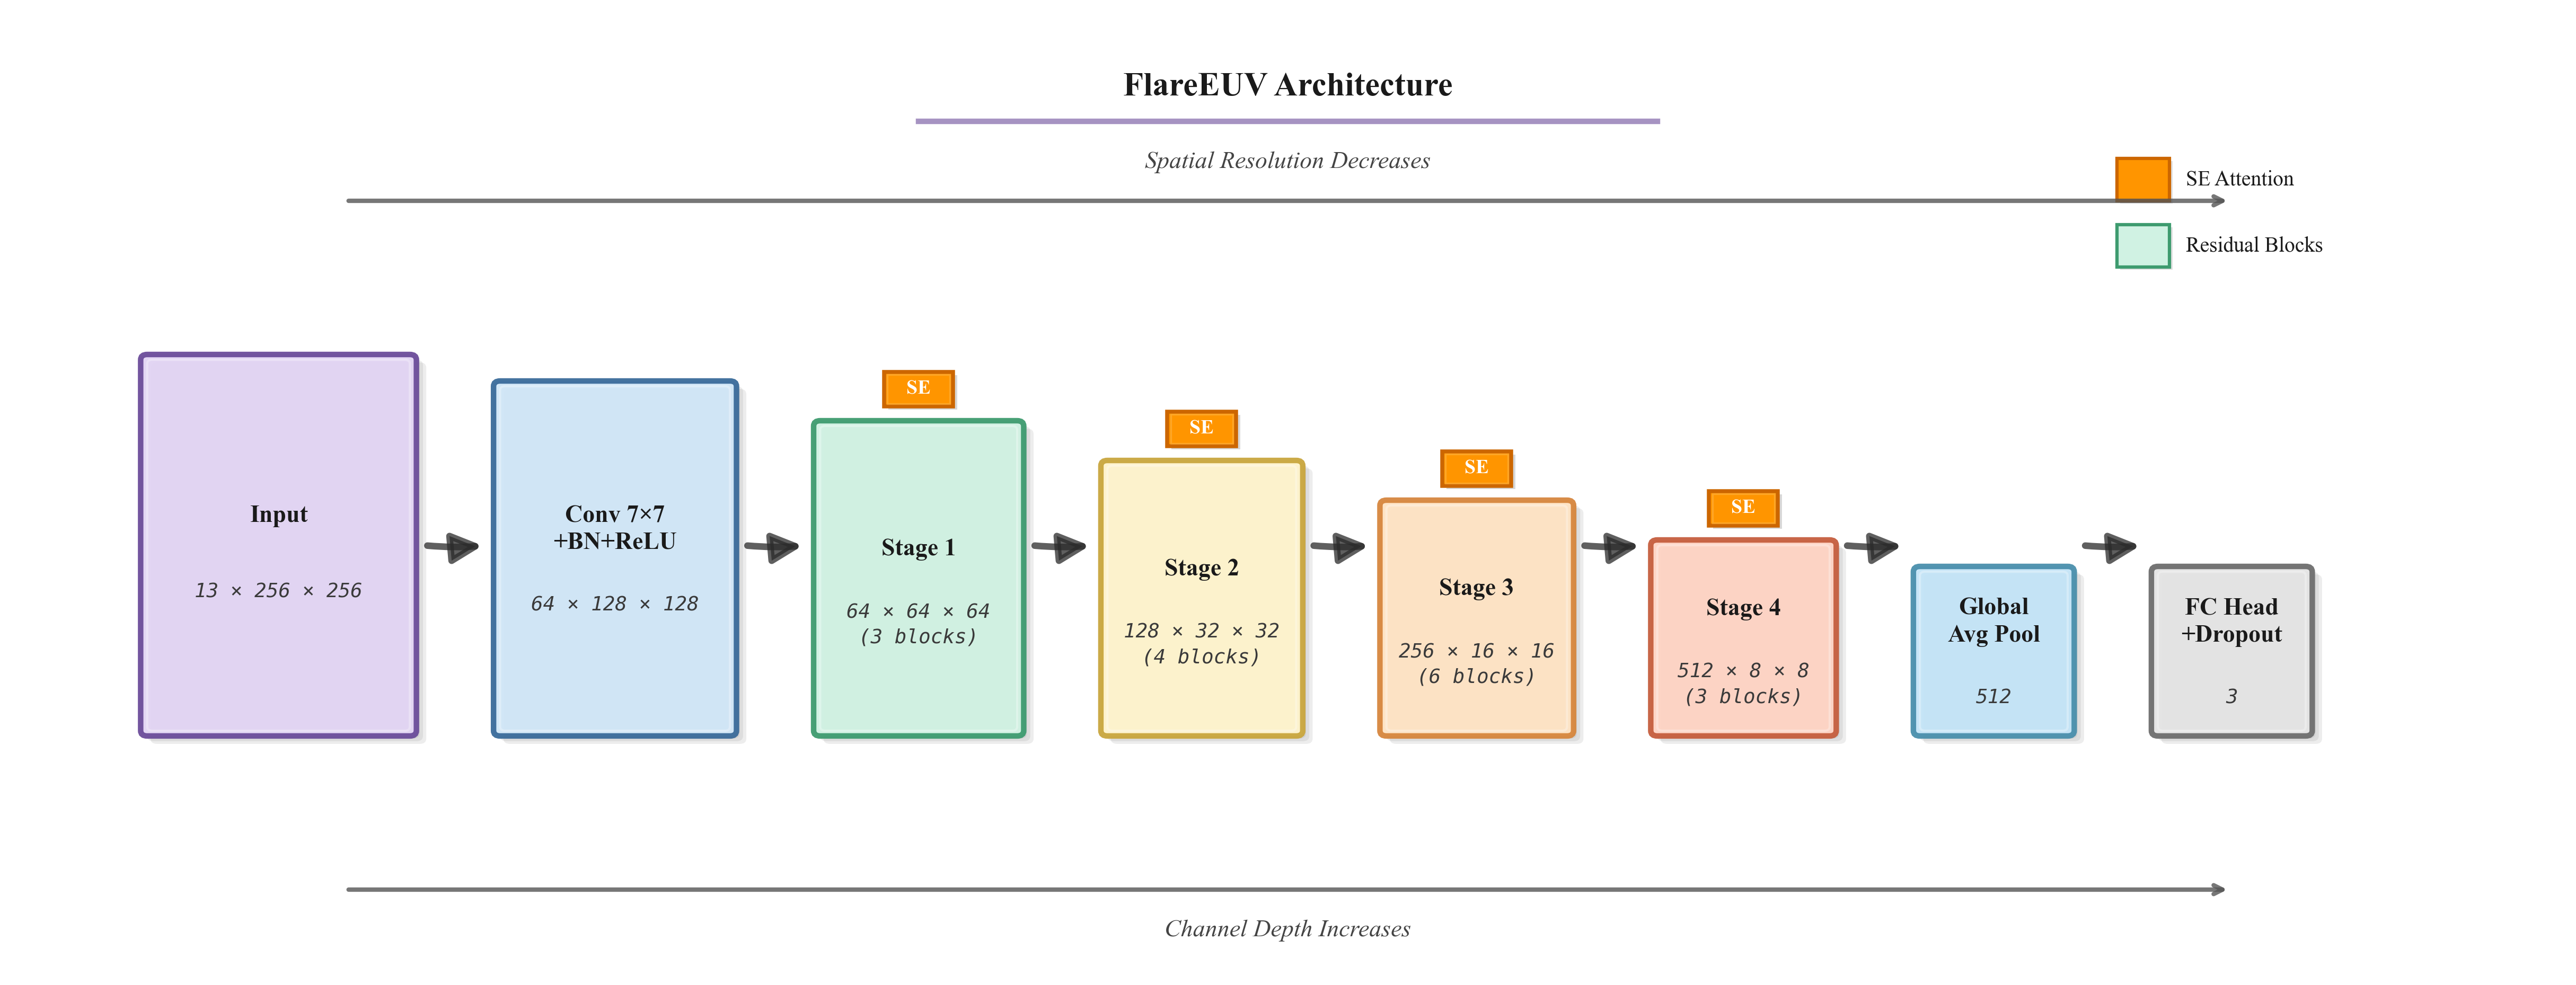

In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Rectangle, Circle
import numpy as np

def create_professional_architecture():
    """Create the most professional architecture diagram possible"""
    
    # IEEE style with enhanced settings
    plt.rcParams.update({
        'font.family': 'serif',
        'font.serif': ['Times New Roman', 'DejaVu Serif'],
        'font.size': 10,
        'axes.labelweight': 'bold',
        'figure.dpi': 300,
        'savefig.dpi': 300,
        'savefig.bbox': 'tight',
        'savefig.pad_inches': 0.1
    })
    
    fig, ax = plt.subplots(figsize=(16, 6), dpi=300)
    
    # Enhanced color palette (gradient effect)
    stages = [
        # (name, width, height, dims_text, fill_color, edge_color, y_offset)
        ("Input", 1.6, 2.8, "13 × 256 × 256", '#E3D5F5', '#6B4C9A', 0),
        ("Conv 7×7\n+BN+ReLU", 1.4, 2.6, "64 × 128 × 128", '#D1E7F8', '#3A6B9A', -0.1),
        ("Stage 1", 1.2, 2.3, "64 × 64 × 64\n(3 blocks)", '#D0F2E3', '#3E9B6F', -0.25),
        ("Stage 2", 1.15, 2.0, "128 × 32 × 32\n(4 blocks)", '#FFF4CC', '#C9A63E', -0.4),
        ("Stage 3", 1.1, 1.7, "256 × 16 × 16\n(6 blocks)", '#FFE4C4', '#D6863E', -0.55),
        ("Stage 4", 1.05, 1.4, "512 × 8 × 8\n(3 blocks)", '#FFD4C4', '#C55E3E', -0.7),
        ("Global\nAvg Pool", 0.9, 1.2, "512", '#C4E5F8', '#4A8FAC', -0.8),
        ("FC Head\n+Dropout", 0.9, 1.2, "3", '#E5E5E5', '#6E6E6E', -0.8)
    ]
    
    x_pos = 0.8
    spacing = 0.55
    base_y = 3.2
    
    box_positions = []
    
    for i, (name, width, height, dims, fill_color, edge_color, y_offset) in enumerate(stages):
        y = base_y - height/2 + y_offset
        
        # Enhanced shadow (multiple layers for depth)
        for shadow_offset in [0.06, 0.04, 0.02]:
            shadow = FancyBboxPatch(
                (x_pos + shadow_offset, y - shadow_offset), width, height,
                boxstyle="round,pad=0.04",
                facecolor='#888888', edgecolor='none',
                alpha=0.15, zorder=1
            )
            ax.add_patch(shadow)
        
        # Main box with gradient-like effect (lighter inner border)
        box = FancyBboxPatch(
            (x_pos, y), width, height,
            boxstyle="round,pad=0.04",
            facecolor=fill_color,
            edgecolor=edge_color,
            linewidth=2.5,
            alpha=0.95,
            zorder=3
        )
        ax.add_patch(box)
        
        # Inner highlight for 3D effect
        inner_box = FancyBboxPatch(
            (x_pos + 0.03, y + 0.03), width - 0.06, height - 0.06,
            boxstyle="round,pad=0.03",
            facecolor='none',
            edgecolor='white',
            linewidth=1.0,
            alpha=0.3,
            zorder=4
        )
        ax.add_patch(inner_box)
        
        # Stage name with better spacing
        name_y = y + height/2 + 0.22
        ax.text(x_pos + width/2, name_y, name,
               ha='center', va='center',
               fontsize=11, weight='bold',
               color='#1A1A1A', zorder=5,
               linespacing=1.3)
        
        # Dimensions with better spacing
        dims_y = y + height/2 - 0.35
        ax.text(x_pos + width/2, dims_y, dims,
               ha='center', va='center',
               fontsize=9, style='italic',
               color='#3A3A3A', family='monospace',
               zorder=5, linespacing=1.4)
        
        # Enhanced SE Attention blocks
        if 2 <= i <= 5:
            se_width = 0.42
            se_height = 0.26
            se_x = x_pos + width/2 - se_width/2
            se_y = y + height + 0.15  # More space from box
            
            # SE shadow
            se_shadow = Rectangle(
                (se_x + 0.025, se_y - 0.025), se_width, se_height,
                facecolor='#666666', edgecolor='none',
                alpha=0.25, zorder=2, transform=ax.transData
            )
            ax.add_patch(se_shadow)
            
            # SE box with gradient
            se_box = Rectangle(
                (se_x, se_y), se_width, se_height,
                facecolor='#FF9500', edgecolor='#CC6600',
                linewidth=1.8, zorder=3
            )
            ax.add_patch(se_box)
            
            # SE highlight
            se_highlight = Rectangle(
                (se_x + 0.02, se_y + 0.02), se_width - 0.04, se_height - 0.04,
                facecolor='none', edgecolor='#FFB84D',
                linewidth=0.8, alpha=0.5, zorder=4
            )
            ax.add_patch(se_highlight)
            
            # SE text
            ax.text(se_x + se_width/2, se_y + se_height/2, 'SE',
                   ha='center', va='center',
                   fontsize=9, weight='bold',
                   color='white', zorder=5)
        
        box_positions.append((x_pos, width, y, height))
        x_pos += width + spacing
    
    # Professional curved arrows
    for i in range(len(box_positions) - 1):
        x1, w1, y1, h1 = box_positions[i]
        x2, w2, y2, h2 = box_positions[i + 1]
        
        start_x = x1 + w1 + 0.08
        end_x = x2 - 0.08
        arrow_y = base_y
        
        # Create slightly curved arrow
        arrow = FancyArrowPatch(
            (start_x, arrow_y),
            (end_x, arrow_y),
            arrowstyle='-|>',
            mutation_scale=28,
            linewidth=3.0,
            color='#2A2A2A',
            alpha=0.75,
            zorder=2,
            connectionstyle="arc3,rad=0.05"  # Slight curve
        )
        ax.add_patch(arrow)
    
    # Enhanced directional indicators with better spacing
    arrow_top_y = 5.8
    arrow_bottom_y = 0.6
    
    # Top arrow (Spatial Resolution)
    ax.annotate('', xy=(13.5, arrow_top_y), xytext=(2.0, arrow_top_y),
               arrowprops=dict(arrowstyle='->', lw=2.0, color='#555555', alpha=0.8))
    ax.text(7.75, arrow_top_y + 0.25, 'Spatial Resolution Decreases',
           fontsize=11, ha='center', style='italic', color='#444444', weight='normal')
    
    # Bottom arrow (Channel Depth)
    ax.annotate('', xy=(13.5, arrow_bottom_y), xytext=(2.0, arrow_bottom_y),
               arrowprops=dict(arrowstyle='->', lw=2.0, color='#555555', alpha=0.8))
    ax.text(7.75, arrow_bottom_y - 0.35, 'Channel Depth Increases',
           fontsize=11, ha='center', style='italic', color='#444444', weight='normal')
    
    # Title with underline decoration
    title_y = 6.6
    ax.text(7.75, title_y, 'FlareEUV Architecture',
           fontsize=15, ha='center', weight='bold', family='serif', color='#1A1A1A')
    
    # Subtle underline
    ax.plot([5.5, 10.0], [title_y - 0.2, title_y - 0.2],
           color='#6B4C9A', linewidth=2.5, alpha=0.6)
    
    # Enhanced legend with boxes and better spacing
    legend_x = 12.8
    legend_y = 5.8
    box_size = 0.32
    text_offset = 0.42
    
    # SE Attention legend
    leg_se_shadow = Rectangle((legend_x + 0.02, legend_y - 0.02), box_size, box_size,
                              facecolor='#666666', edgecolor='none', alpha=0.2)
    ax.add_patch(leg_se_shadow)
    
    leg_se = Rectangle((legend_x, legend_y), box_size, box_size,
                       facecolor='#FF9500', edgecolor='#CC6600', linewidth=1.5)
    ax.add_patch(leg_se)
    
    ax.text(legend_x + text_offset, legend_y + box_size/2,
           'SE Attention',
           va='center', fontsize=9.5, color='#1A1A1A', weight='normal')
    
    # Residual Blocks legend
    leg_y2 = legend_y - 0.5
    leg_res_shadow = Rectangle((legend_x + 0.02, leg_y2 - 0.02), box_size, box_size,
                               facecolor='#666666', edgecolor='none', alpha=0.2)
    ax.add_patch(leg_res_shadow)
    
    leg_res = Rectangle((legend_x, leg_y2), box_size, box_size,
                        facecolor='#D0F2E3', edgecolor='#3E9B6F', linewidth=1.5)
    ax.add_patch(leg_res)
    
    ax.text(legend_x + text_offset, leg_y2 + box_size/2,
           'Residual Blocks',
           va='center', fontsize=9.5, color='#1A1A1A', weight='normal')
    
    # Set limits with proper padding
    ax.set_xlim(0, 15.5)
    ax.set_ylim(0, 7.2)
    ax.axis('off')
    
    # Remove all margins
    plt.tight_layout(pad=0)
    
    # Save in multiple formats with high quality
    formats = {
        'pdf': {'format': 'pdf', 'bbox_inches': 'tight', 'pad_inches': 0.05},
        'png': {'format': 'png', 'dpi': 600, 'bbox_inches': 'tight', 'pad_inches': 0.05},
        'eps': {'format': 'eps', 'bbox_inches': 'tight', 'pad_inches': 0.05},
        'svg': {'format': 'svg', 'bbox_inches': 'tight', 'pad_inches': 0.05}
    }
    
    for fmt, kwargs in formats.items():
        plt.savefig(f'figures/flare_euv_architecture_final.{fmt}', **kwargs)
        print(f"✅ Saved: figures/flare_euv_architecture_final.{fmt}")
    
    plt.show()


if __name__ == "__main__":
    create_professional_architecture()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


✅ Perfect version saved!
   - PDF: figures/flare_euv_architecture_perfect.pdf
   - PNG: figures/flare_euv_architecture_perfect.png
   - EPS: figures/flare_euv_architecture_perfect.eps


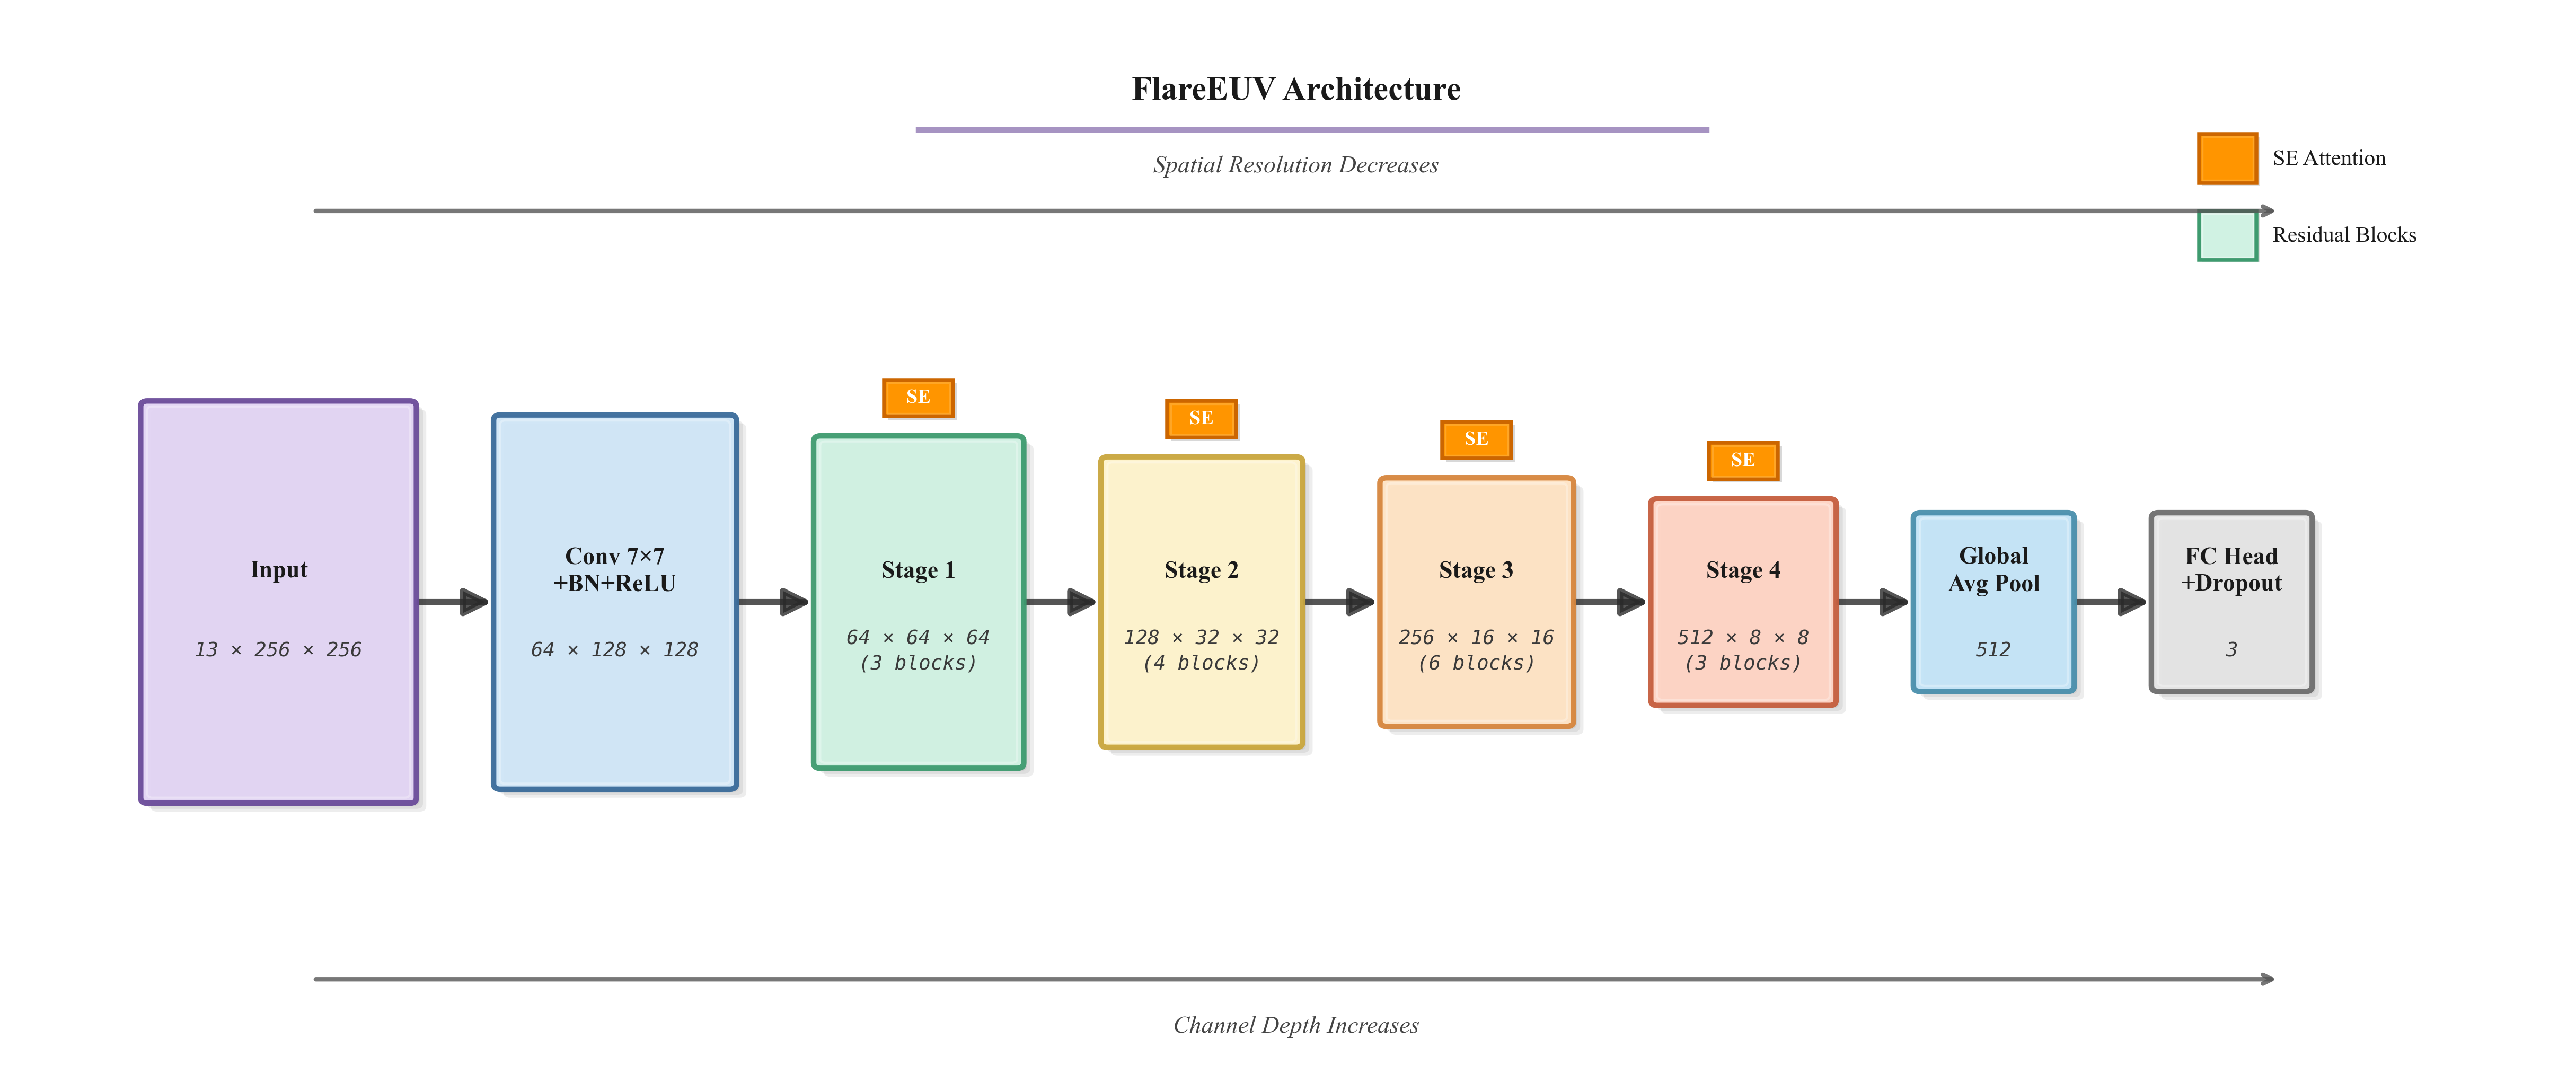

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Rectangle
import numpy as np

def create_final_architecture():
    """Create the absolute best architecture diagram"""
    
    plt.rcParams.update({
        'font.family': 'serif',
        'font.serif': ['Times New Roman', 'DejaVu Serif'],
        'font.size': 10,
        'axes.labelweight': 'bold',
        'figure.dpi': 300
    })
    
    fig, ax = plt.subplots(figsize=(16, 6.5), dpi=300)
    
    # Stages with consistent vertical alignment
    stages = [
        ("Input", 1.6, 2.8, "13 × 256 × 256", '#E3D5F5', '#6B4C9A'),
        ("Conv 7×7\n+BN+ReLU", 1.4, 2.6, "64 × 128 × 128", '#D1E7F8', '#3A6B9A'),
        ("Stage 1", 1.2, 2.3, "64 × 64 × 64\n(3 blocks)", '#D0F2E3', '#3E9B6F'),
        ("Stage 2", 1.15, 2.0, "128 × 32 × 32\n(4 blocks)", '#FFF4CC', '#C9A63E'),
        ("Stage 3", 1.1, 1.7, "256 × 16 × 16\n(6 blocks)", '#FFE4C4', '#D6863E'),
        ("Stage 4", 1.05, 1.4, "512 × 8 × 8\n(3 blocks)", '#FFD4C4', '#C55E3E'),
        ("Global\nAvg Pool", 0.9, 1.2, "512", '#C4E5F8', '#4A8FAC'),
        ("FC Head\n+Dropout", 0.9, 1.2, "3", '#E5E5E5', '#6E6E6E')
    ]
    
    x_pos = 0.8
    spacing = 0.55
    base_y = 3.2  # Fixed vertical center
    
    box_positions = []
    
    # Draw all boxes
    for i, (name, width, height, dims, fill_color, edge_color) in enumerate(stages):
        y = base_y - height/2
        
        # Shadow layers
        for shadow_offset in [0.06, 0.04, 0.02]:
            shadow = FancyBboxPatch(
                (x_pos + shadow_offset, y - shadow_offset), width, height,
                boxstyle="round,pad=0.04",
                facecolor='#888888', edgecolor='none',
                alpha=0.15, zorder=1
            )
            ax.add_patch(shadow)
        
        # Main box
        box = FancyBboxPatch(
            (x_pos, y), width, height,
            boxstyle="round,pad=0.04",
            facecolor=fill_color,
            edgecolor=edge_color,
            linewidth=2.5,
            alpha=0.95,
            zorder=3
        )
        ax.add_patch(box)
        
        # Inner highlight
        inner_box = FancyBboxPatch(
            (x_pos + 0.03, y + 0.03), width - 0.06, height - 0.06,
            boxstyle="round,pad=0.03",
            facecolor='none',
            edgecolor='white',
            linewidth=1.0,
            alpha=0.3,
            zorder=4
        )
        ax.add_patch(inner_box)
        
        # Text
        name_y = y + height/2 + 0.22
        ax.text(x_pos + width/2, name_y, name,
               ha='center', va='center',
               fontsize=11, weight='bold',
               color='#1A1A1A', zorder=5,
               linespacing=1.3)
        
        dims_y = y + height/2 - 0.35
        ax.text(x_pos + width/2, dims_y, dims,
               ha='center', va='center',
               fontsize=9, style='italic',
               color='#3A3A3A', family='monospace',
               zorder=5, linespacing=1.4)
        
        # SE blocks
        if 2 <= i <= 5:
            se_width = 0.42
            se_height = 0.26
            se_x = x_pos + width/2 - se_width/2
            se_y = y + height + 0.18
            
            se_shadow = Rectangle(
                (se_x + 0.025, se_y - 0.025), se_width, se_height,
                facecolor='#666666', edgecolor='none',
                alpha=0.25, zorder=2
            )
            ax.add_patch(se_shadow)
            
            se_box = Rectangle(
                (se_x, se_y), se_width, se_height,
                facecolor='#FF9500', edgecolor='#CC6600',
                linewidth=1.8, zorder=3
            )
            ax.add_patch(se_box)
            
            se_highlight = Rectangle(
                (se_x + 0.02, se_y + 0.02), se_width - 0.04, se_height - 0.04,
                facecolor='none', edgecolor='#FFB84D',
                linewidth=0.8, alpha=0.5, zorder=4
            )
            ax.add_patch(se_highlight)
            
            ax.text(se_x + se_width/2, se_y + se_height/2, 'SE',
                   ha='center', va='center',
                   fontsize=9, weight='bold',
                   color='white', zorder=5)
        
        box_positions.append((x_pos, width, y, height))
        x_pos += width + spacing
    
    # FIXED ARROWS - Perfectly horizontal at center
    for i in range(len(box_positions) - 1):
        x1, w1, y1, h1 = box_positions[i]
        x2, w2, y2, h2 = box_positions[i + 1]
        
        # Calculate center y for both boxes
        center_y1 = y1 + h1/2
        center_y2 = y2 + h2/2
        arrow_y = (center_y1 + center_y2) / 2  # Midpoint between centers
        
        start_x = x1 + w1 + 0.05
        end_x = x2 - 0.05
        
        # Perfectly straight horizontal arrow
        arrow = FancyArrowPatch(
            (start_x, arrow_y),
            (end_x, arrow_y),
            arrowstyle='-|>',
            mutation_scale=25,
            linewidth=2.8,
            color='#2A2A2A',
            alpha=0.8,
            zorder=2,
            shrinkA=0,
            shrinkB=0
        )
        ax.add_patch(arrow)
    
    # Directional indicators
    arrow_top_y = 6.0
    arrow_bottom_y = 0.5
    indicator_start = 1.8
    indicator_end = 13.8
    
    # Top arrow
    ax.annotate('', xy=(indicator_end, arrow_top_y), xytext=(indicator_start, arrow_top_y),
               arrowprops=dict(arrowstyle='->', lw=2.0, color='#555555', alpha=0.8))
    ax.text((indicator_start + indicator_end)/2, arrow_top_y + 0.28,
           'Spatial Resolution Decreases',
           fontsize=11, ha='center', style='italic', color='#444444')
    
    # Bottom arrow
    ax.annotate('', xy=(indicator_end, arrow_bottom_y), xytext=(indicator_start, arrow_bottom_y),
               arrowprops=dict(arrowstyle='->', lw=2.0, color='#555555', alpha=0.8))
    ax.text((indicator_start + indicator_end)/2, arrow_bottom_y - 0.38,
           'Channel Depth Increases',
           fontsize=11, ha='center', style='italic', color='#444444')
    
    # Title
    title_y = 6.8
    ax.text((indicator_start + indicator_end)/2, title_y, 'FlareEUV Architecture',
           fontsize=15, ha='center', weight='bold', family='serif', color='#1A1A1A')
    
    # Underline
    ax.plot([5.5, 10.3], [title_y - 0.22, title_y - 0.22],
           color='#6B4C9A', linewidth=2.5, alpha=0.6)
    
    # LEGEND - Top Right Corner (FIXED)
    legend_x = 13.3
    legend_y_start = 6.2
    box_size = 0.35
    text_offset = 0.45
    spacing = 0.55
    
    # SE Attention
    leg_se_shadow = Rectangle(
        (legend_x + 0.02, legend_y_start - 0.02), box_size, box_size,
        facecolor='#666666', edgecolor='none', alpha=0.2, zorder=1
    )
    ax.add_patch(leg_se_shadow)
    
    leg_se = Rectangle(
        (legend_x, legend_y_start), box_size, box_size,
        facecolor='#FF9500', edgecolor='#CC6600', linewidth=1.8, zorder=2
    )
    ax.add_patch(leg_se)
    
    leg_se_highlight = Rectangle(
        (legend_x + 0.02, legend_y_start + 0.02), box_size - 0.04, box_size - 0.04,
        facecolor='none', edgecolor='#FFB84D', linewidth=0.8, alpha=0.5, zorder=3
    )
    ax.add_patch(leg_se_highlight)
    
    ax.text(legend_x + text_offset, legend_y_start + box_size/2,
           'SE Attention',
           va='center', fontsize=10, color='#1A1A1A', weight='normal')
    
    # Residual Blocks
    leg_y2 = legend_y_start - spacing
    leg_res_shadow = Rectangle(
        (legend_x + 0.02, leg_y2 - 0.02), box_size, box_size,
        facecolor='#666666', edgecolor='none', alpha=0.2, zorder=1
    )
    ax.add_patch(leg_res_shadow)
    
    leg_res = Rectangle(
        (legend_x, leg_y2), box_size, box_size,
        facecolor='#D0F2E3', edgecolor='#3E9B6F', linewidth=1.8, zorder=2
    )
    ax.add_patch(leg_res)
    
    leg_res_highlight = Rectangle(
        (legend_x + 0.02, leg_y2 + 0.02), box_size - 0.04, box_size - 0.04,
        facecolor='none', edgecolor='white', linewidth=0.8, alpha=0.4, zorder=3
    )
    ax.add_patch(leg_res_highlight)
    
    ax.text(legend_x + text_offset, leg_y2 + box_size/2,
           'Residual Blocks',
           va='center', fontsize=10, color='#1A1A1A', weight='normal')
    
    # Set limits
    ax.set_xlim(0, 15.5)
    ax.set_ylim(0, 7.4)
    ax.axis('off')
    
    plt.tight_layout(pad=0)
    
    # Save
    plt.savefig('figures/flare_euv_architecture_perfect.pdf',
               dpi=600, bbox_inches='tight', pad_inches=0.05, format='pdf')
    plt.savefig('figures/flare_euv_architecture_perfect.png',
               dpi=600, bbox_inches='tight', pad_inches=0.05, format='png')
    plt.savefig('figures/flare_euv_architecture_perfect.eps',
               bbox_inches='tight', pad_inches=0.05, format='eps')
    
    print("✅ Perfect version saved!")
    print("   - PDF: figures/flare_euv_architecture_perfect.pdf")
    print("   - PNG: figures/flare_euv_architecture_perfect.png")
    print("   - EPS: figures/flare_euv_architecture_perfect.eps")
    
    plt.show()


if __name__ == "__main__":
    create_final_architecture()

Creating FlareEUV architecture diagram...
Saving figure...
✅ Saved: figures/flare_euv_architecture_final.pdf


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


✅ Saved: figures/flare_euv_architecture_final.png
✅ Saved: figures/flare_euv_architecture_final.eps
✅ Saved: figures/flare_euv_architecture_final.svg

🎉 All formats saved successfully!
📁 Location: figures/ folder
📄 Use .pdf for your LaTeX paper


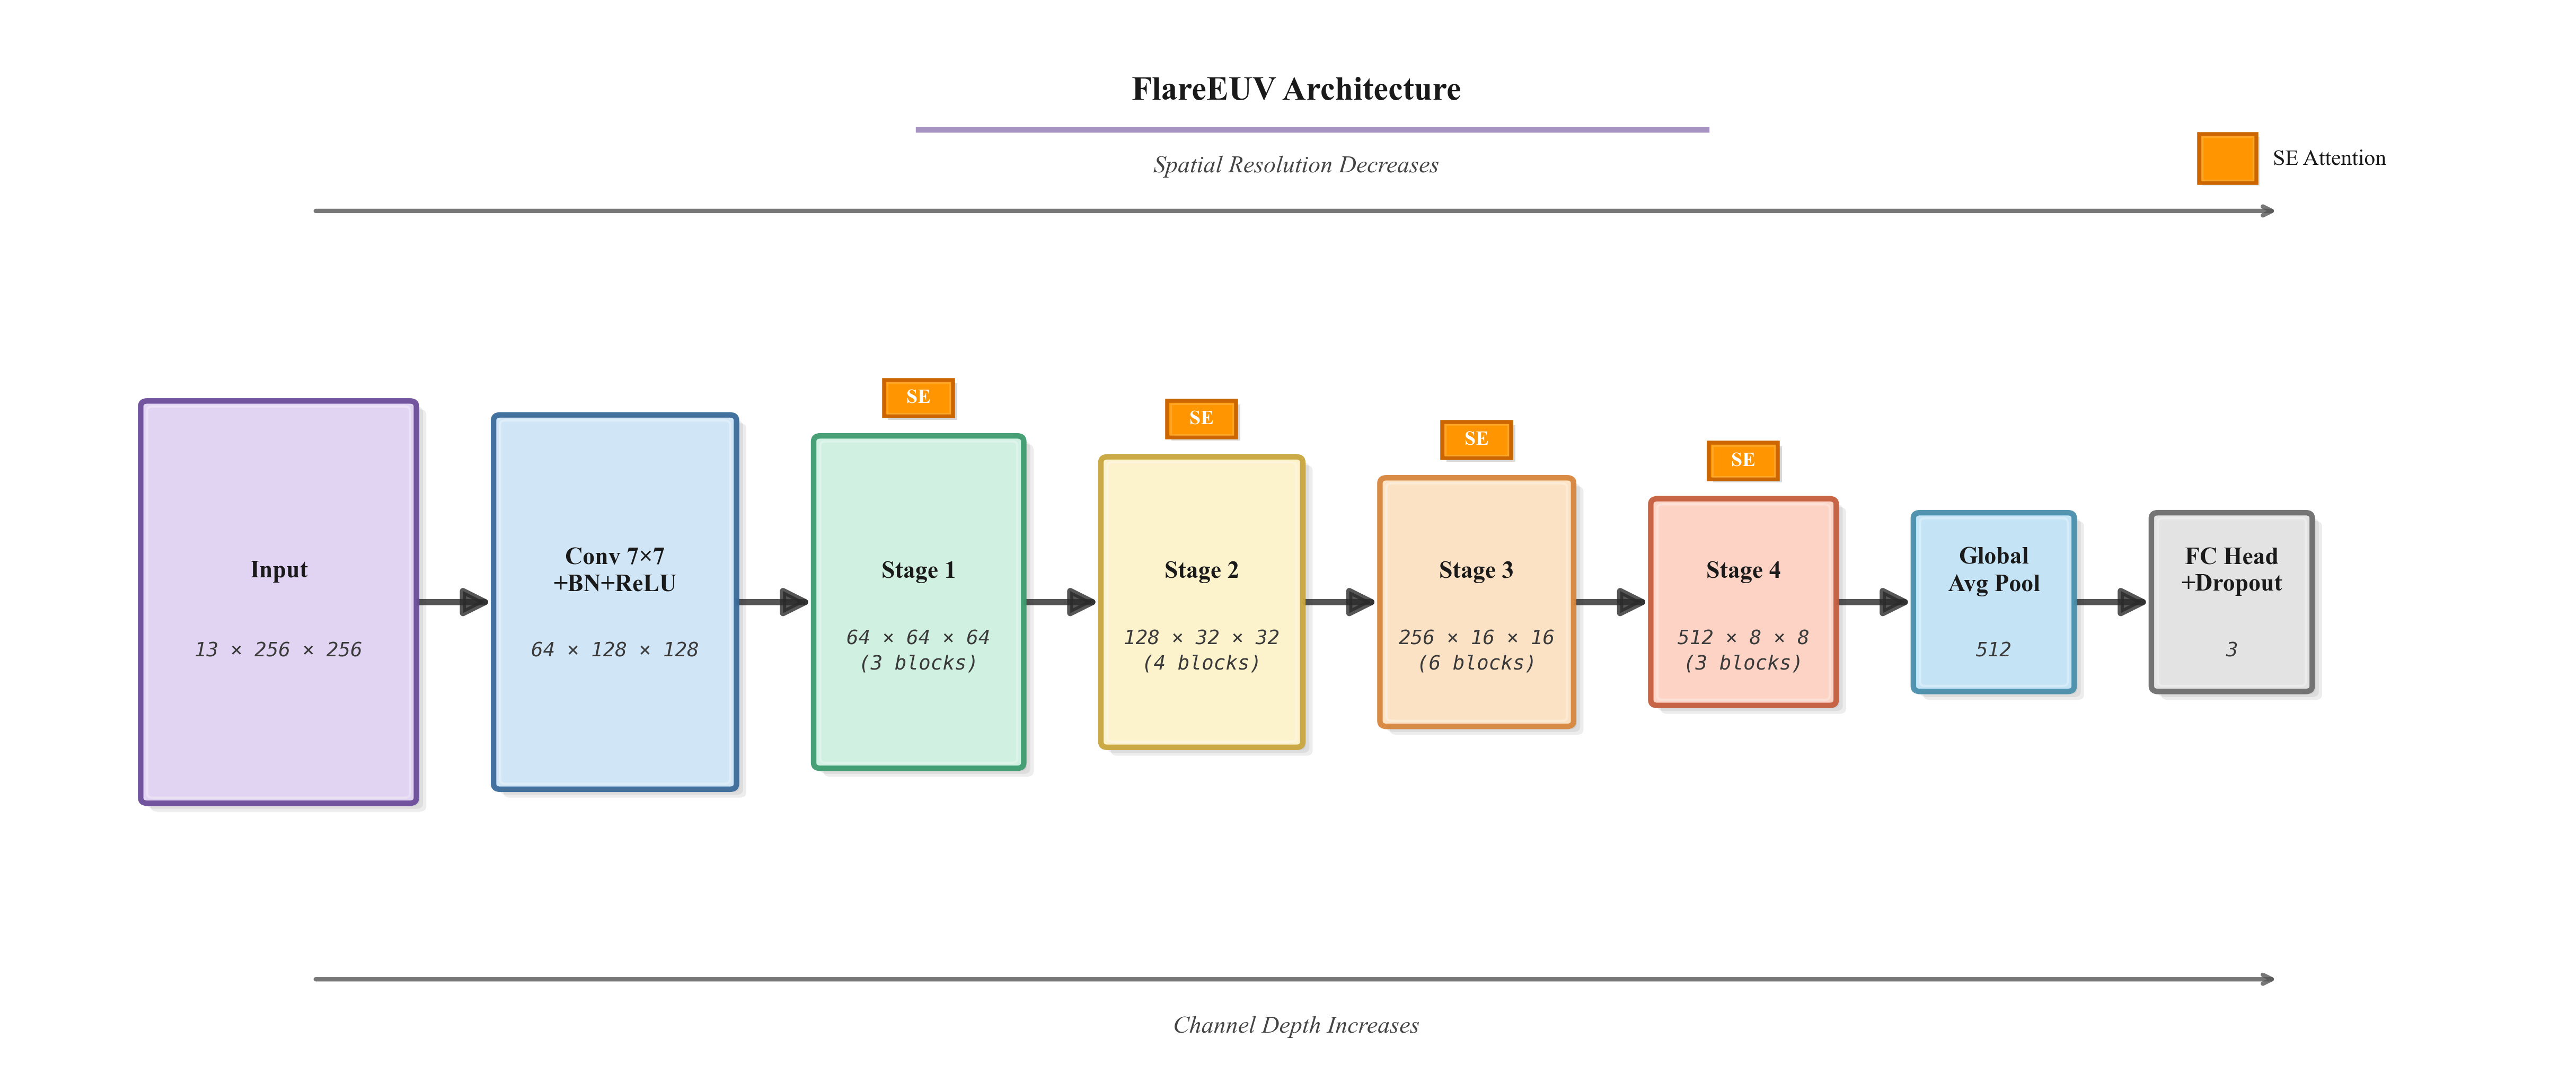

✅ Done! Ready to add to your paper.


In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Rectangle
import numpy as np

def create_perfect_architecture():
    """Create the absolute best FlareEUV architecture diagram"""
    
    # IEEE style parameters
    plt.rcParams.update({
        'font.family': 'serif',
        'font.serif': ['Times New Roman', 'DejaVu Serif'],
        'font.size': 10,
        'axes.labelweight': 'bold',
        'figure.dpi': 300,
        'savefig.dpi': 600,
        'savefig.bbox': 'tight'
    })
    
    fig, ax = plt.subplots(figsize=(16, 6.5), dpi=300)
    
    # Stage definitions with professional color palette
    stages = [
        # (name, width, height, dims_text, fill_color, edge_color)
        ("Input", 1.6, 2.8, "13 × 256 × 256", '#E3D5F5', '#6B4C9A'),
        ("Conv 7×7\n+BN+ReLU", 1.4, 2.6, "64 × 128 × 128", '#D1E7F8', '#3A6B9A'),
        ("Stage 1", 1.2, 2.3, "64 × 64 × 64\n(3 blocks)", '#D0F2E3', '#3E9B6F'),
        ("Stage 2", 1.15, 2.0, "128 × 32 × 32\n(4 blocks)", '#FFF4CC', '#C9A63E'),
        ("Stage 3", 1.1, 1.7, "256 × 16 × 16\n(6 blocks)", '#FFE4C4', '#D6863E'),
        ("Stage 4", 1.05, 1.4, "512 × 8 × 8\n(3 blocks)", '#FFD4C4', '#C55E3E'),
        ("Global\nAvg Pool", 0.9, 1.2, "512", '#C4E5F8', '#4A8FAC'),
        ("FC Head\n+Dropout", 0.9, 1.2, "3", '#E5E5E5', '#6E6E6E')
    ]
    
    x_pos = 0.8
    spacing = 0.55
    base_y = 3.2  # Fixed vertical center for consistent alignment
    
    box_positions = []
    
    # ============================================================
    # Draw all stage boxes
    # ============================================================
    for i, (name, width, height, dims, fill_color, edge_color) in enumerate(stages):
        y = base_y - height/2
        
        # Multi-layer shadow for depth effect
        for shadow_offset in [0.06, 0.04, 0.02]:
            shadow = FancyBboxPatch(
                (x_pos + shadow_offset, y - shadow_offset), width, height,
                boxstyle="round,pad=0.04",
                facecolor='#888888', 
                edgecolor='none',
                alpha=0.15, 
                zorder=1
            )
            ax.add_patch(shadow)
        
        # Main box
        box = FancyBboxPatch(
            (x_pos, y), width, height,
            boxstyle="round,pad=0.04",
            facecolor=fill_color,
            edgecolor=edge_color,
            linewidth=2.5,
            alpha=0.95,
            zorder=3
        )
        ax.add_patch(box)
        
        # Inner highlight for 3D effect
        inner_box = FancyBboxPatch(
            (x_pos + 0.03, y + 0.03), width - 0.06, height - 0.06,
            boxstyle="round,pad=0.03",
            facecolor='none',
            edgecolor='white',
            linewidth=1.0,
            alpha=0.3,
            zorder=4
        )
        ax.add_patch(inner_box)
        
        # Stage name (bold, top)
        name_y = y + height/2 + 0.22
        ax.text(x_pos + width/2, name_y, name,
               ha='center', va='center',
               fontsize=11, weight='bold',
               color='#1A1A1A', zorder=5,
               linespacing=1.3)
        
        # Dimensions (italic, bottom)
        dims_y = y + height/2 - 0.35
        ax.text(x_pos + width/2, dims_y, dims,
               ha='center', va='center',
               fontsize=9, style='italic',
               color='#3A3A3A', 
               family='monospace',
               zorder=5, 
               linespacing=1.4)
        
        # ============================================================
        # SE Attention blocks (for stages 1-4 only)
        # ============================================================
        if 2 <= i <= 5:
            se_width = 0.42
            se_height = 0.26
            se_x = x_pos + width/2 - se_width/2
            se_y = y + height + 0.18  # Proper spacing above box
            
            # SE shadow
            se_shadow = Rectangle(
                (se_x + 0.025, se_y - 0.025), se_width, se_height,
                facecolor='#666666', 
                edgecolor='none',
                alpha=0.25, 
                zorder=2
            )
            ax.add_patch(se_shadow)
            
            # SE main box
            se_box = Rectangle(
                (se_x, se_y), se_width, se_height,
                facecolor='#FF9500', 
                edgecolor='#CC6600',
                linewidth=1.8, 
                zorder=3
            )
            ax.add_patch(se_box)
            
            # SE highlight
            se_highlight = Rectangle(
                (se_x + 0.02, se_y + 0.02), 
                se_width - 0.04, se_height - 0.04,
                facecolor='none', 
                edgecolor='#FFB84D',
                linewidth=0.8, 
                alpha=0.5, 
                zorder=4
            )
            ax.add_patch(se_highlight)
            
            # SE text
            ax.text(se_x + se_width/2, se_y + se_height/2, 'SE',
                   ha='center', va='center',
                   fontsize=9, weight='bold',
                   color='white', zorder=5)
        
        # Store position for arrows
        box_positions.append((x_pos, width, y, height))
        x_pos += width + spacing
    
    # ============================================================
    # Draw arrows between stages (PERFECTLY HORIZONTAL)
    # ============================================================
    for i in range(len(box_positions) - 1):
        x1, w1, y1, h1 = box_positions[i]
        x2, w2, y2, h2 = box_positions[i + 1]
        
        # Calculate center y-coordinate for both boxes
        center_y1 = y1 + h1/2
        center_y2 = y2 + h2/2
        arrow_y = (center_y1 + center_y2) / 2  # Midpoint = perfect horizontal
        
        start_x = x1 + w1 + 0.05
        end_x = x2 - 0.05
        
        # Perfectly straight horizontal arrow
        arrow = FancyArrowPatch(
            (start_x, arrow_y),
            (end_x, arrow_y),
            arrowstyle='-|>',
            mutation_scale=25,
            linewidth=2.8,
            color='#2A2A2A',
            alpha=0.8,
            zorder=2,
            shrinkA=0,
            shrinkB=0
        )
        ax.add_patch(arrow)
    
    # ============================================================
    # Directional indicators (top and bottom)
    # ============================================================
    arrow_top_y = 6.0
    arrow_bottom_y = 0.5
    indicator_start = 1.8
    indicator_end = 13.8
    
    # Top arrow: Spatial Resolution Decreases
    ax.annotate('', 
               xy=(indicator_end, arrow_top_y), 
               xytext=(indicator_start, arrow_top_y),
               arrowprops=dict(arrowstyle='->', lw=2.0, 
                             color='#555555', alpha=0.8))
    ax.text((indicator_start + indicator_end)/2, arrow_top_y + 0.28,
           'Spatial Resolution Decreases',
           fontsize=11, ha='center', style='italic', color='#444444')
    
    # Bottom arrow: Channel Depth Increases
    ax.annotate('', 
               xy=(indicator_end, arrow_bottom_y), 
               xytext=(indicator_start, arrow_bottom_y),
               arrowprops=dict(arrowstyle='->', lw=2.0, 
                             color='#555555', alpha=0.8))
    ax.text((indicator_start + indicator_end)/2, arrow_bottom_y - 0.38,
           'Channel Depth Increases',
           fontsize=11, ha='center', style='italic', color='#444444')
    
    # ============================================================
    # Title with decorative underline
    # ============================================================
    title_y = 6.8
    ax.text((indicator_start + indicator_end)/2, title_y, 
           'FlareEUV Architecture',
           fontsize=15, ha='center', weight='bold', 
           family='serif', color='#1A1A1A')
    
    # Decorative underline
    ax.plot([5.5, 10.3], [title_y - 0.22, title_y - 0.22],
           color='#6B4C9A', linewidth=2.5, alpha=0.6)
    
    # ============================================================
    # LEGEND - Top Right Corner (ONLY SE Attention)
    # ============================================================
    legend_x = 13.3
    legend_y = 6.2
    box_size = 0.35
    text_offset = 0.45
    
    # SE Attention box shadow
    leg_se_shadow = Rectangle(
        (legend_x + 0.02, legend_y - 0.02), box_size, box_size,
        facecolor='#666666', 
        edgecolor='none', 
        alpha=0.2, 
        zorder=1
    )
    ax.add_patch(leg_se_shadow)
    
    # SE Attention box
    leg_se = Rectangle(
        (legend_x, legend_y), box_size, box_size,
        facecolor='#FF9500', 
        edgecolor='#CC6600', 
        linewidth=1.8, 
        zorder=2
    )
    ax.add_patch(leg_se)
    
    # SE Attention highlight
    leg_se_highlight = Rectangle(
        (legend_x + 0.02, legend_y + 0.02), 
        box_size - 0.04, box_size - 0.04,
        facecolor='none', 
        edgecolor='#FFB84D', 
        linewidth=0.8, 
        alpha=0.5, 
        zorder=3
    )
    ax.add_patch(leg_se_highlight)
    
    # SE Attention label
    ax.text(legend_x + text_offset, legend_y + box_size/2,
           'SE Attention',
           va='center', fontsize=10, 
           color='#1A1A1A', weight='normal')
    
    # ============================================================
    # Set limits and finalize
    # ============================================================
    ax.set_xlim(0, 15.5)
    ax.set_ylim(0, 7.4)
    ax.axis('off')
    
    plt.tight_layout(pad=0)
    
    # ============================================================
    # Save in multiple formats
    # ============================================================
    print("Saving figure...")
    
    # PDF (vector, perfect for LaTeX)
    plt.savefig('figures/flare_euv_architecture_final.pdf',
               format='pdf', dpi=600, 
               bbox_inches='tight', pad_inches=0.05)
    print("✅ Saved: figures/flare_euv_architecture_final.pdf")
    
    # PNG (high-res raster for presentations)
    plt.savefig('figures/flare_euv_architecture_final.png',
               format='png', dpi=600, 
               bbox_inches='tight', pad_inches=0.05)
    print("✅ Saved: figures/flare_euv_architecture_final.png")
    
    # EPS (for some journals)
    plt.savefig('figures/flare_euv_architecture_final.eps',
               format='eps', 
               bbox_inches='tight', pad_inches=0.05)
    print("✅ Saved: figures/flare_euv_architecture_final.eps")
    
    # SVG (for editing/web)
    plt.savefig('figures/flare_euv_architecture_final.svg',
               format='svg', 
               bbox_inches='tight', pad_inches=0.05)
    print("✅ Saved: figures/flare_euv_architecture_final.svg")
    
    print("\n🎉 All formats saved successfully!")
    print("📁 Location: figures/ folder")
    print("📄 Use .pdf for your LaTeX paper")
    
    plt.show()


if __name__ == "__main__":
    import os
    
    # Create figures directory if it doesn't exist
    os.makedirs('figures', exist_ok=True)
    print("Creating FlareEUV architecture diagram...")
    print("="*60)
    
    create_perfect_architecture()
    
    print("="*60)
    print("✅ Done! Ready to add to your paper.")

In [6]:
# ============================================================
# LOAD SAVED HMI-ONLY PREDICTIONS (FROM results_hmi_only/)
# ============================================================
import numpy as np
import glob

all_preds = []
all_trues = []

files = sorted(glob.glob("results_hmi_only/*_preds.npz"))
print(f"Found {len(files)} prediction files...")

for f in files:
    data = np.load(f)
    all_preds.append(data["preds"])
    all_trues.append(data["trues"])

# Convert to numpy arrays
all_preds = np.vstack(all_preds)   # shape: (33, 3)
all_trues = np.vstack(all_trues)   # shape: (33, 3)

print("\nLoaded prediction arrays:")
print(f"  all_preds shape: {all_preds.shape}")
print(f"  all_trues shape: {all_trues.shape}")

# Compute global metrics
from sklearn.metrics import mean_absolute_error
from scipy.stats import pearsonr

global_mae = mean_absolute_error(all_trues.ravel(), all_preds.ravel())
global_r, _ = pearsonr(all_trues.ravel(), all_preds.ravel())

print("\nGlobal Metrics (HMI-Only):")
print(f"  Pearson r = {global_r:.3f}")
print(f"  MAE = {global_mae:.2e} W/m²/nm")


Found 33 prediction files...

Loaded prediction arrays:
  all_preds shape: (33, 3)
  all_trues shape: (33, 3)

Global Metrics (HMI-Only):
  Pearson r = 0.835
  MAE = 7.32e-06 W/m²/nm



GENERATING GLOBAL SCATTER PLOT — IEEE STYLE (HMI-ONLY, MAX SIZE)

📌 Saved in IEEE format:
   figures_ieee/global_scatter_hmi_only.pdf
   figures_ieee/global_scatter_hmi_only.png


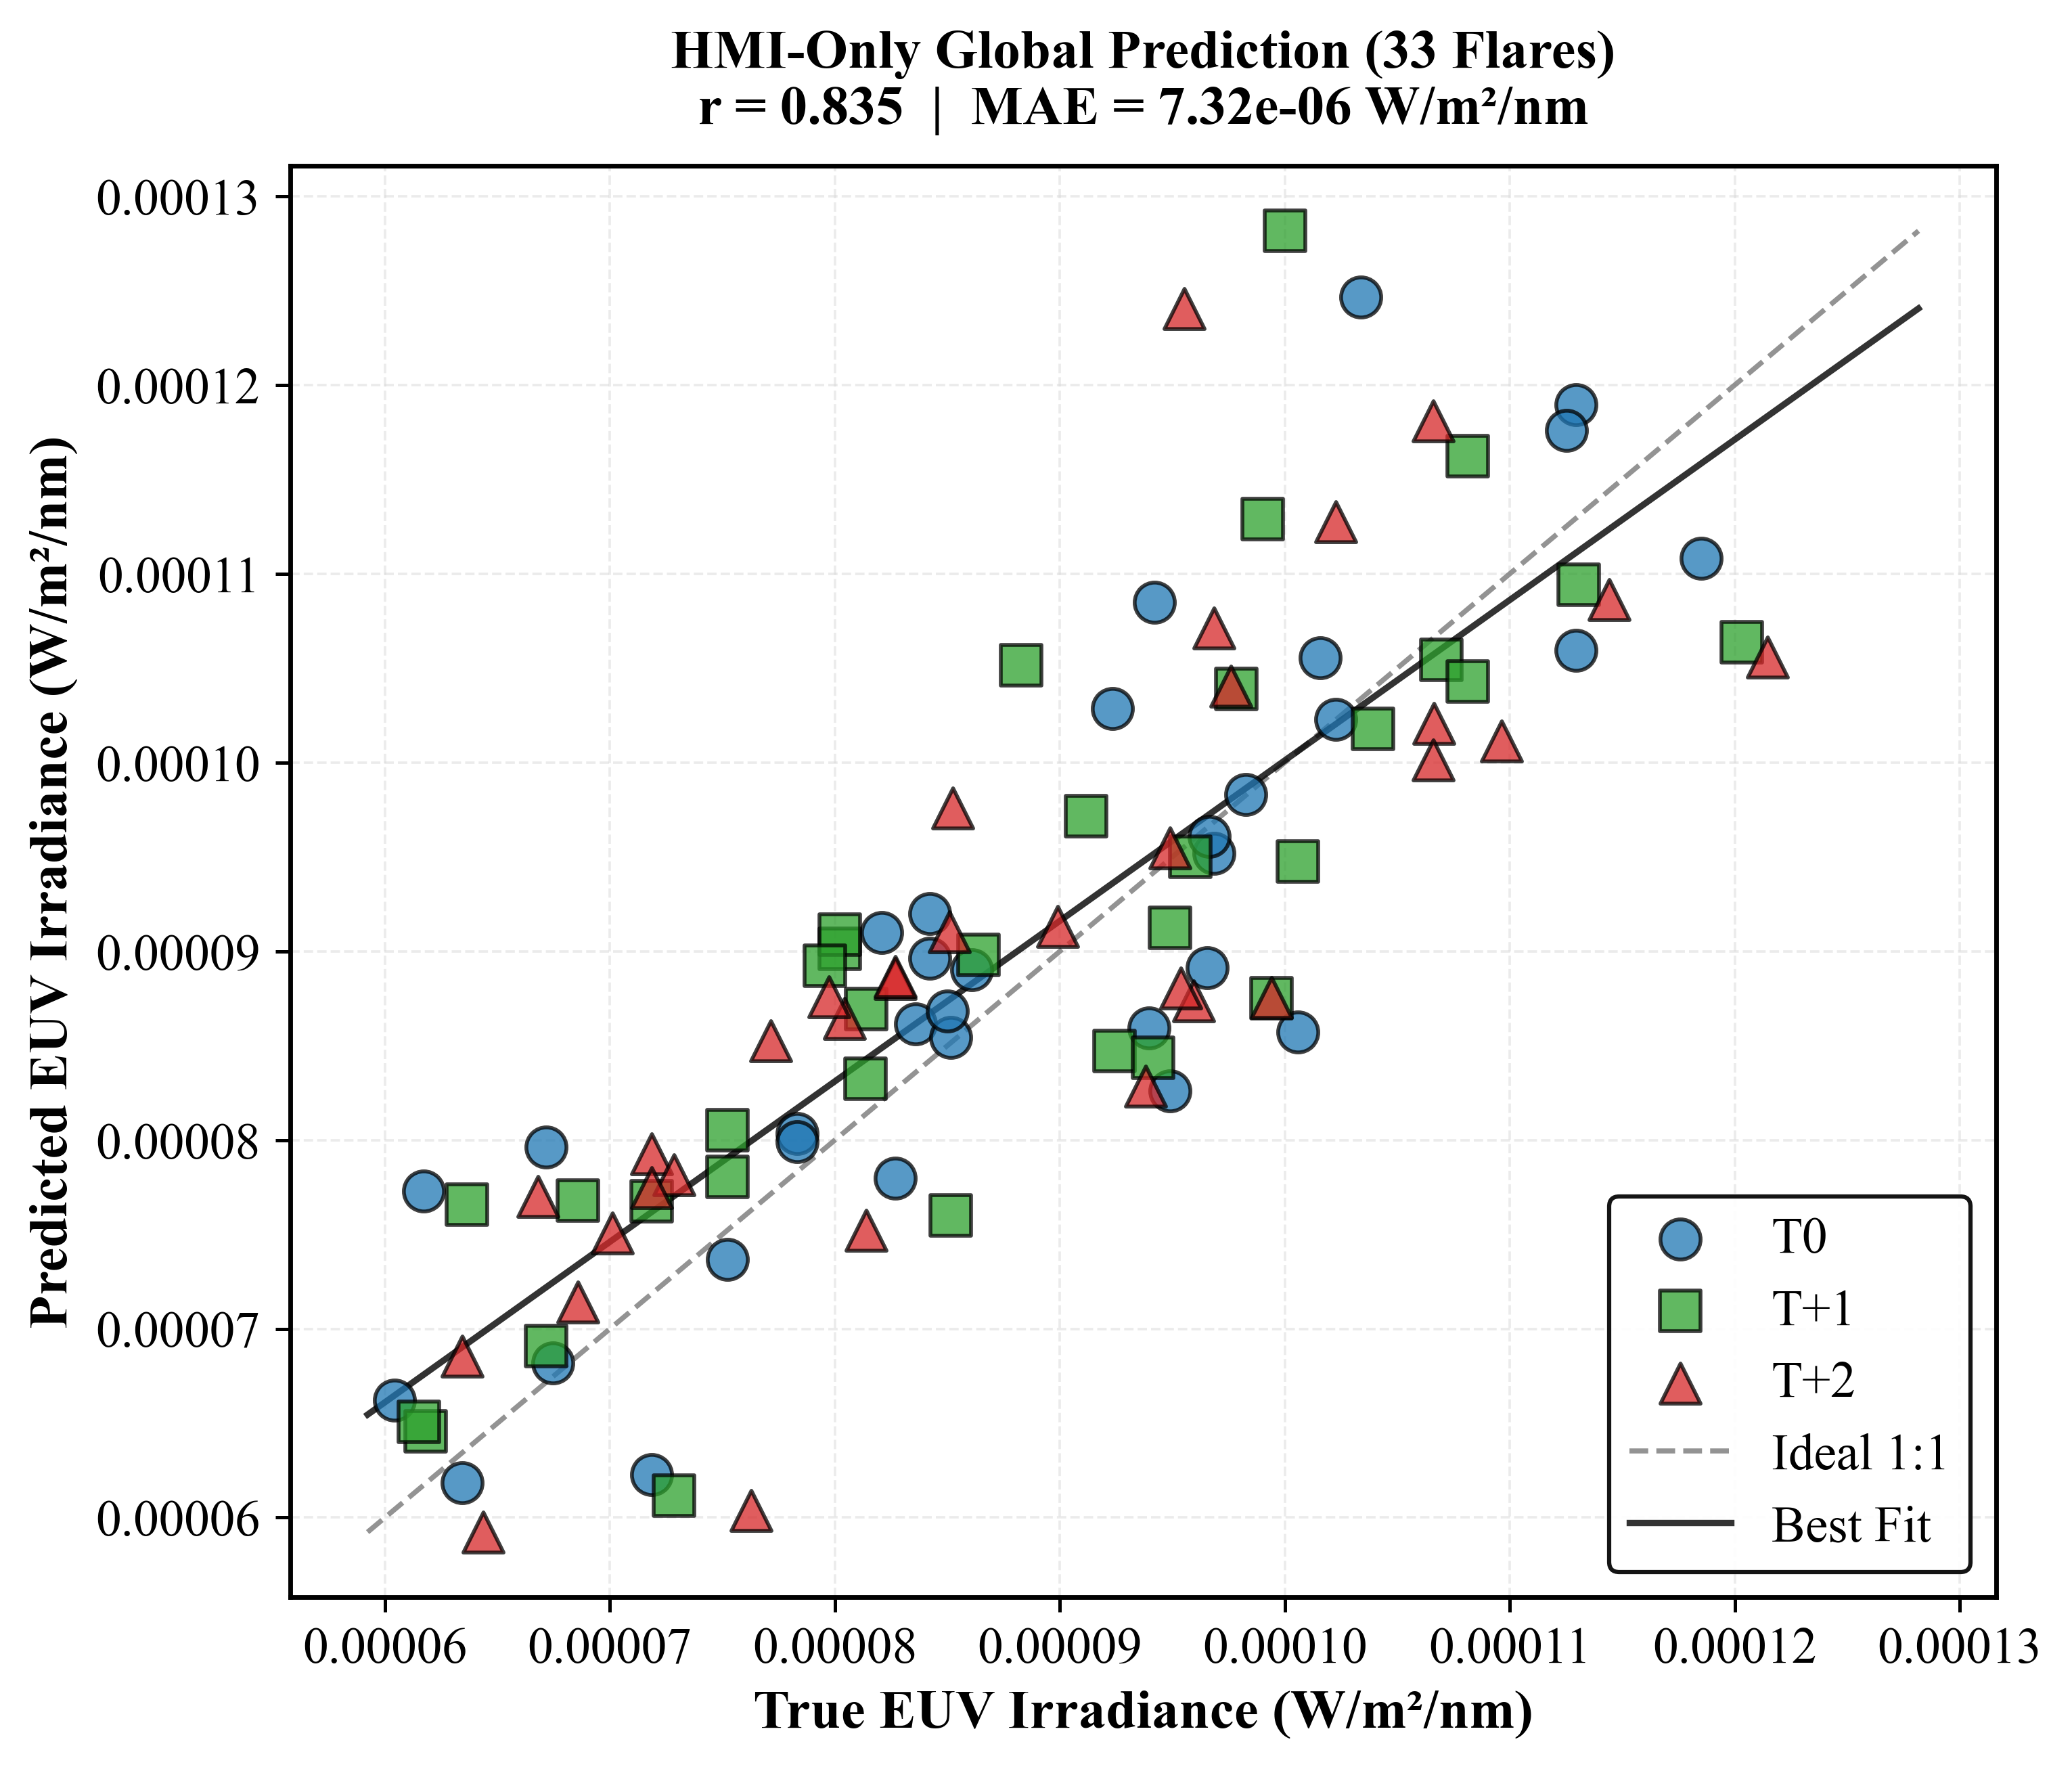

In [14]:
# %%
# ============================================================
# GLOBAL SCATTER PLOT – IEEE STYLE (HMI-ONLY, MAX SIZE)
# ============================================================

from matplotlib import rcParams
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt
import os

# --- IEEE FONT & STYLE (BIGGER FOR MAX READABILITY) ---
rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 13,           # ← Increased
    "axes.labelsize": 13,
    "axes.titlesize": 13,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "axes.linewidth": 1.1,
})

print("\n" + "="*70)
print("GENERATING GLOBAL SCATTER PLOT — IEEE STYLE (HMI-ONLY, MAX SIZE)")
print("="*70)

# --- Flatten arrays ---
preds_flat = all_preds.ravel()
trues_flat = all_trues.ravel()

# --- Figure (MAX SIZE – FULL 2-COLUMN WIDTH) ---
fig, ax = plt.subplots(figsize=(7.0, 6.0), dpi=450)   #  🔥 MAX SIZE (SAFE)

# --- MARKERS & COLORS ---
markers = ['o', 's', '^']
colors  = ['#1f77b4', '#2ca02c', '#d62728']
labels  = ['T0', 'T+1', 'T+2']

for i, (marker, color, label) in enumerate(zip(markers, colors, labels)):
    ax.scatter(all_trues[:, i], all_preds[:, i],
               s=90, marker=marker,          # ← LARGER
               c=color, alpha=0.75,
               edgecolors='black', linewidth=0.9,
               label=label, zorder=3)

# --- 1:1 LINE ---
min_val = min(trues_flat.min(), preds_flat.min())
max_val = max(trues_flat.max(), preds_flat.max())
ax.plot([min_val, max_val], [min_val, max_val], '--',
        lw=1.2, alpha=0.85, color="gray", label="Ideal 1:1")

# --- REGRESSION LINE ---
lr = LinearRegression()
lr.fit(trues_flat.reshape(-1, 1), preds_flat)
line = lr.predict(np.array([min_val, max_val]).reshape(-1, 1))
ax.plot([min_val, max_val], line,
        lw=1.5, linestyle='-', alpha=0.8,
        color="black", label="Best Fit")

# --- TITLE ---
ax.set_title(
    f'HMI-Only Global Prediction (33 Flares)\n'
    f'r = {global_r:.3f}  |  MAE = {global_mae:.2e} W/m²/nm',
    fontweight='bold', pad=10
)

# --- AXIS LABELS ---
ax.set_xlabel('True EUV Irradiance (W/m²/nm)', fontweight='bold')
ax.set_ylabel('Predicted EUV Irradiance (W/m²/nm)', fontweight='bold')

# --- LEGEND BOX ---
legend = ax.legend(loc='lower right', frameon=True, edgecolor='black')
legend.get_frame().set_alpha(0.92)
legend.get_frame().set_linewidth(1.0)

# --- GRID ---
ax.grid(alpha=0.5, linestyle='--', linewidth=0.6)

plt.tight_layout()

# --- SAVE HIGH QUALITY (IEEE SUBMISSION FORMAT) ---
os.makedirs("figures_ieee", exist_ok=True)
plt.savefig("figures_ieee/global_scatter_hmi_only.pdf", dpi=600, bbox_inches='tight')
plt.savefig("figures_ieee/global_scatter_hmi_only.png", dpi=600, bbox_inches='tight')

print("\n📌 Saved in IEEE format:")
print("   figures_ieee/global_scatter_hmi_only.pdf")
print("   figures_ieee/global_scatter_hmi_only.png")
plt.show()



--- HMI-ONLY GLOBAL METRICS ---
PCC = 0.8355 (p=5.75e-27)
MAE = 7.32e-06 W/m²/nm

GENERATING GLOBAL SCATTER PLOT — IEEE STYLE (HMI-ONLY, MAX SIZE)

📌 Saved in IEEE format:
   figures_ieee/global_scatter_hmi_only.pdf
   figures_ieee/global_scatter_hmi_only.png


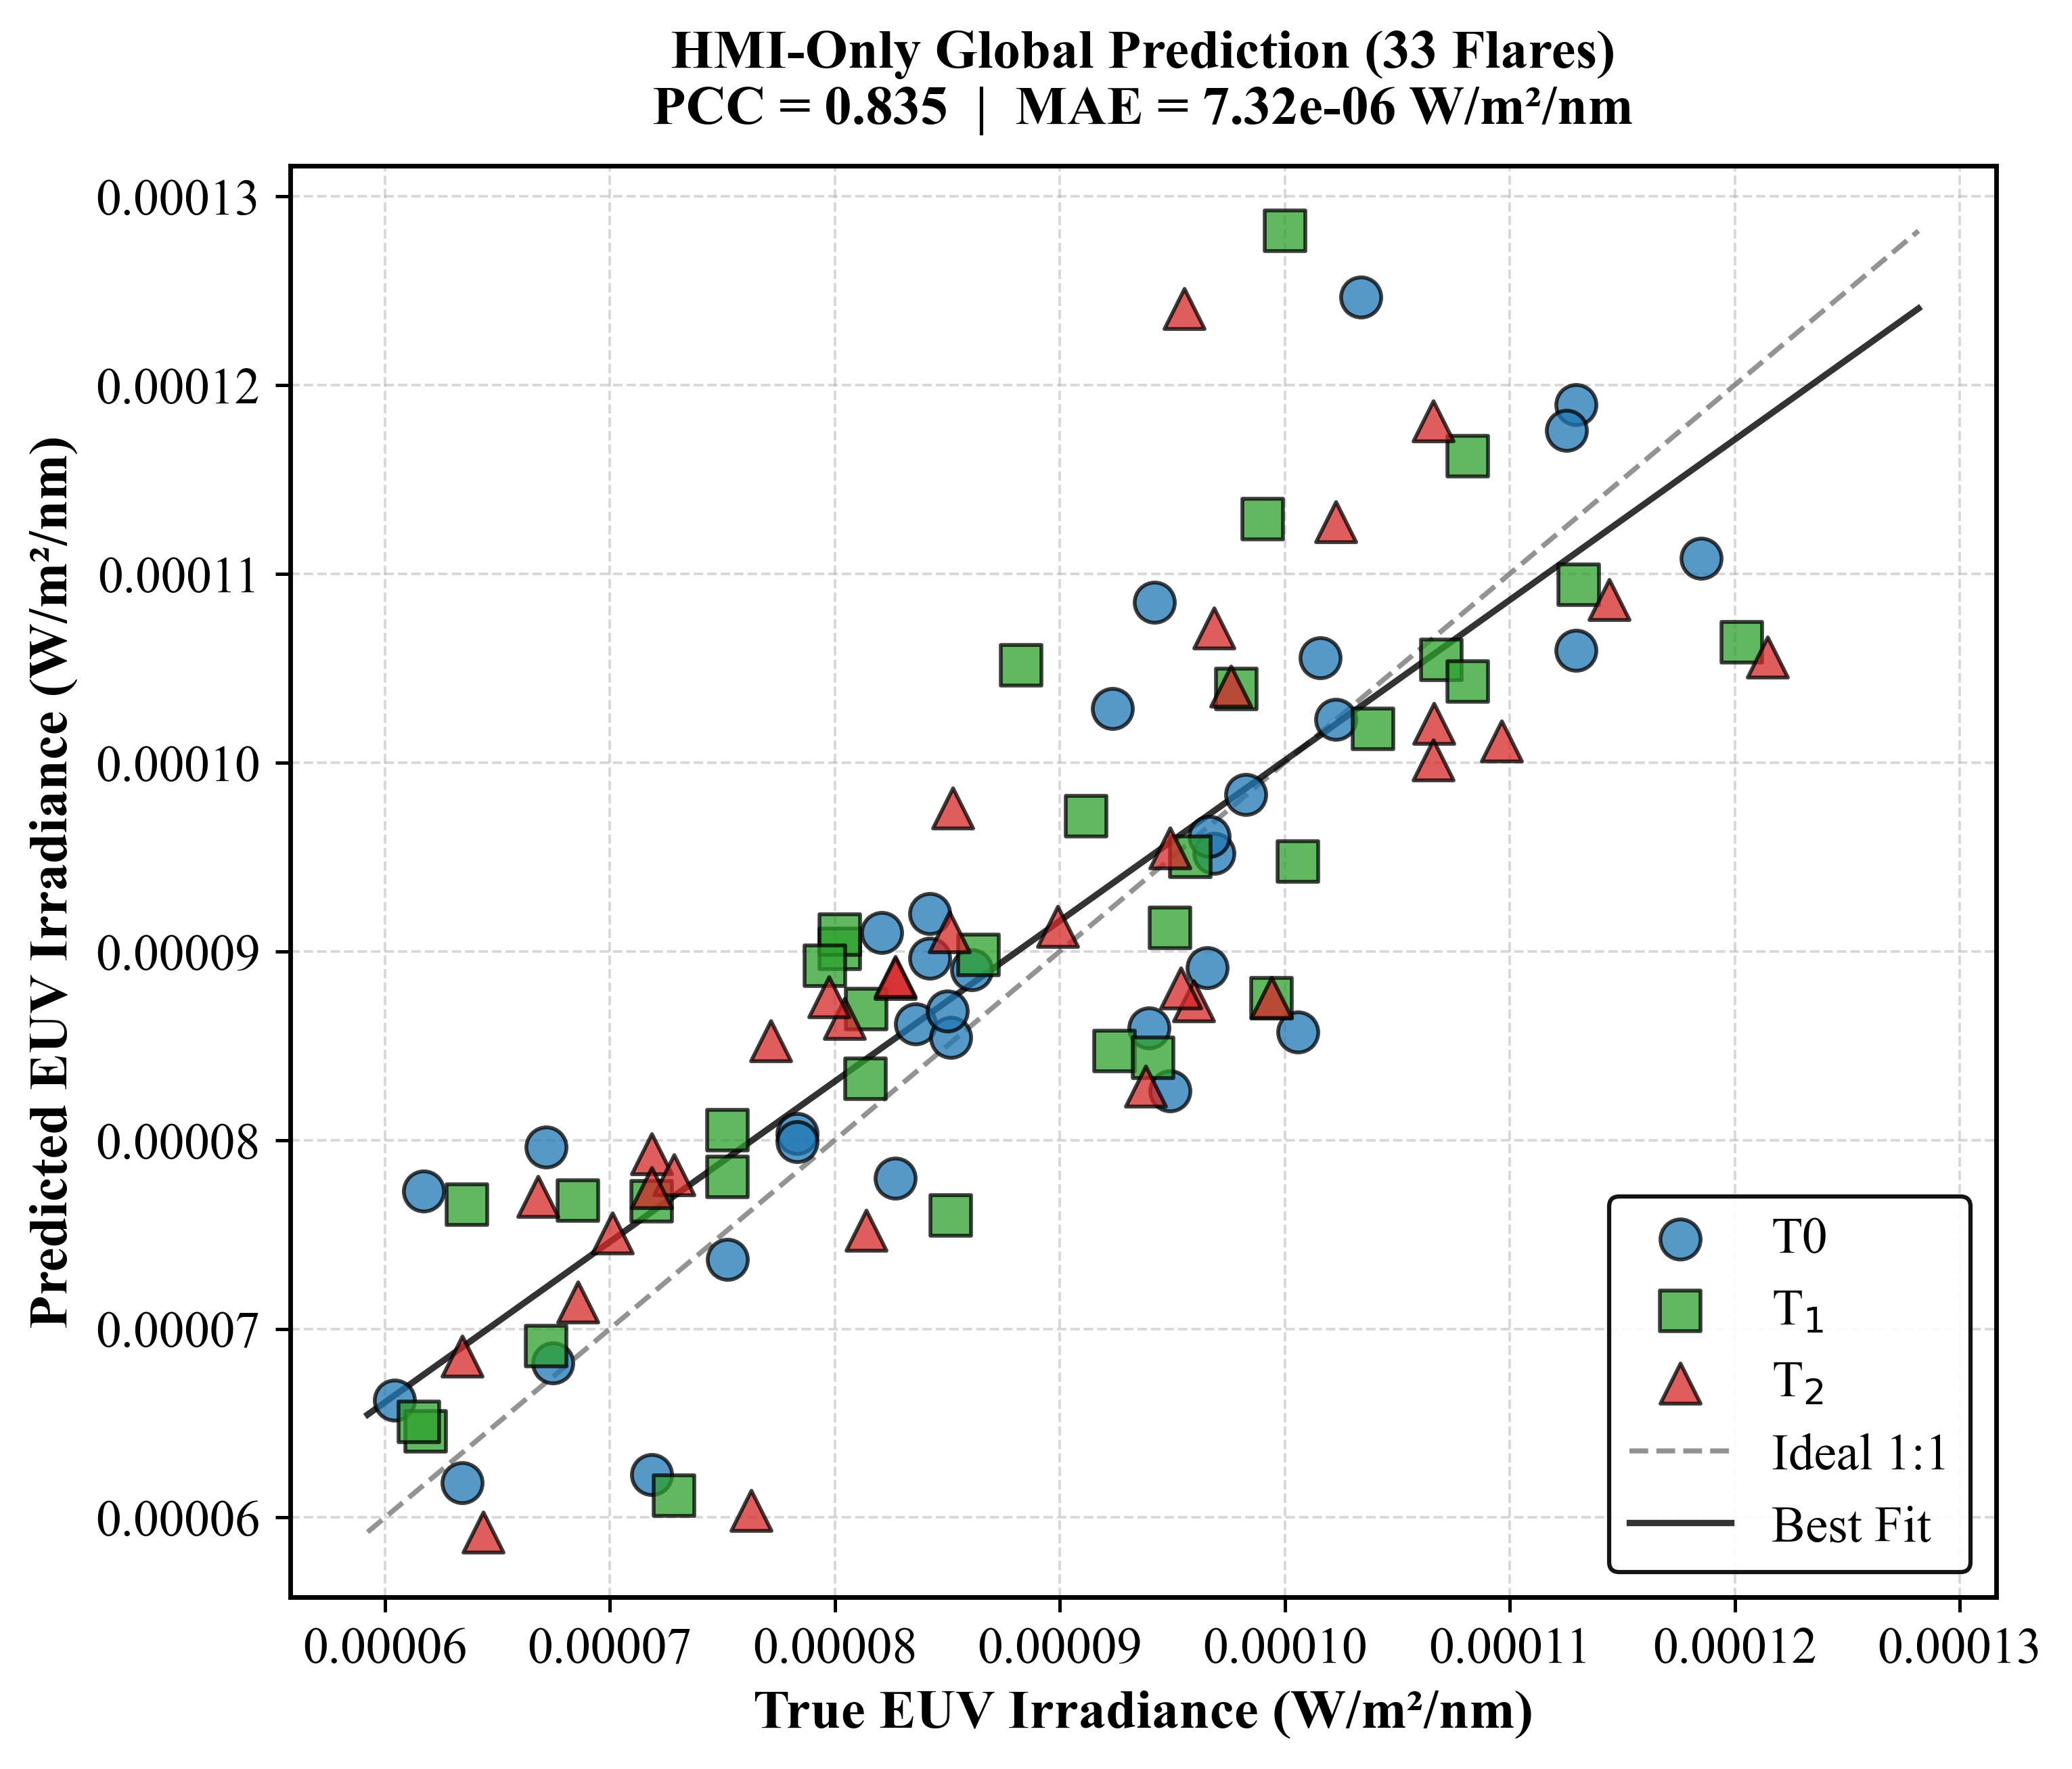

In [3]:
# %%
# ============================================================
# GLOBAL SCATTER PLOT – IEEE STYLE (HMI-ONLY, MAX SIZE)
# ============================================================

from matplotlib import rcParams
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from scipy.stats import pearsonr
import numpy as np
import matplotlib.pyplot as plt
import os

# --- LOAD RESULTS (HMI-ONLY) ---
results_folder = "results_hmi_only"   # ✅ FIXED
all_preds, all_trues = [], []

for npz_file in sorted(os.listdir(results_folder)):
    if npz_file.endswith("_preds.npz"):
        data = np.load(os.path.join(results_folder, npz_file))
        all_preds.append(data["preds"])
        all_trues.append(data["trues"])

all_preds = np.concatenate(all_preds, axis=0)   # shape (N, 3)
all_trues = np.concatenate(all_trues, axis=0)   # shape (N, 3)

# --- Flatten arrays ---
preds_flat = all_preds.ravel()
trues_flat = all_trues.ravel()

# --- METRICS ---
global_r, pvalue = pearsonr(trues_flat, preds_flat)
global_mae = mean_absolute_error(trues_flat, preds_flat)

print("\n--- HMI-ONLY GLOBAL METRICS ---")
print(f"PCC = {global_r:.4f} (p={pvalue:.2e})")
print(f"MAE = {global_mae:.2e} W/m²/nm")

# --- IEEE FONT & STYLE (BIGGER FOR MAX READABILITY) ---
rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 13,
    "axes.labelsize": 13,
    "axes.titlesize": 13,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "axes.linewidth": 1.1,
})

print("\n" + "="*70)
print("GENERATING GLOBAL SCATTER PLOT — IEEE STYLE (HMI-ONLY, MAX SIZE)")
print("="*70)

# --- Figure (MAX SIZE – FULL 2-COLUMN WIDTH) ---
fig, ax = plt.subplots(figsize=(7.0, 6.0), dpi=450)

# --- MARKERS & COLORS ---
markers = ['o', 's', '^']
colors  = ['#1f77b4', '#2ca02c', '#d62728']
labels  = ['T0', r'T$_1$', r'T$_2$']   # IEEE subscripts

for i, (marker, color, label) in enumerate(zip(markers, colors, labels)):
    ax.scatter(all_trues[:, i], all_preds[:, i],
               s=90, marker=marker,
               c=color, alpha=0.75,
               edgecolors='black', linewidth=0.9,
               label=label, zorder=3)

# --- 1:1 LINE ---
min_val = min(trues_flat.min(), preds_flat.min())
max_val = max(trues_flat.max(), preds_flat.max())
ax.plot([min_val, max_val], [min_val, max_val], '--',
        lw=1.2, alpha=0.85, color="gray", label="Ideal 1:1")

# --- REGRESSION LINE ---
lr = LinearRegression()
lr.fit(trues_flat.reshape(-1, 1), preds_flat)
line = lr.predict(np.array([min_val, max_val]).reshape(-1, 1))
ax.plot([min_val, max_val], line,
        lw=1.5, linestyle='-', alpha=0.8,
        color="black", label="Best Fit")

# --- TITLE ---
ax.set_title(
    f'HMI-Only Global Prediction (33 Flares)\n'
    f'PCC = {global_r:.3f}  |  MAE = {global_mae:.2e} W/m²/nm',
    fontweight='bold', pad=10
)

# --- AXIS LABELS ---
ax.set_xlabel('True EUV Irradiance (W/m²/nm)', fontweight='bold')
ax.set_ylabel('Predicted EUV Irradiance (W/m²/nm)', fontweight='bold')

# --- LEGEND BOX ---
legend = ax.legend(loc='lower right', frameon=True, edgecolor='black')
legend.get_frame().set_alpha(0.92)
legend.get_frame().set_linewidth(1.0)

# --- GRID ---
ax.grid(alpha=0.5, linestyle='--', linewidth=0.6)

plt.tight_layout()

# --- SAVE HIGH QUALITY (IEEE SUBMISSION FORMAT) ---
os.makedirs("figures_ieee", exist_ok=True)
plt.savefig("figures_ieee/global_scatter_hmi_only.pdf", dpi=600, bbox_inches='tight')
plt.savefig("figures_ieee/global_scatter_hmi_only.png", dpi=600, bbox_inches='tight')

print("\n📌 Saved in IEEE format:")
print("   figures_ieee/global_scatter_hmi_only.pdf")
print("   figures_ieee/global_scatter_hmi_only.png")
plt.show()
